In [1]:
import mujoco
import numpy as np

# 定义不同的 solref 参数
solref_parameters = [
    "-2e3 0",  # 原始参数
    "-2e5 0",   # 中等刚度
    # "-2e6 0",   # 中等刚度
    "-3e6 0",   # 中等刚度
    "-2e8 0"    # 较低刚度
]

# 存储所有仿真结果
all_results = []

# 运行三次不同参数的仿真
for param_idx, solref in enumerate(solref_parameters):
    print(f"运行仿真 {param_idx+1}, solref={solref}")
    
    # MuJoCo模型XML字符串，使用当前参数
    MUJOCO_MODEL_XML = f"""
<mujoco>
  <option timestep="0.001"/>

  <default>
    <geom solref="{solref}"/>
  </default>
  
  <worldbody>
    <!-- 地面 -->
    <geom name="ground" type="plane" size="10 10 1" pos="0 0 0" rgba="0.8 0.9 0.8 1"/>
    
    <!-- 墙壁 -->
    <geom name="wall1" type="box" size="0.1 10 1" pos="-10 0 1" rgba="0.8 0.8 0.9 1"/>
    <geom name="wall2" type="box" size="0.1 10 1" pos="10 0 1" rgba="0.8 0.8 0.9 1"/>
    <geom name="wall3" type="box" size="10 0.1 1" pos="0 -10 1" rgba="0.8 0.8 0.9 1"/>
    <geom name="wall4" type="box" size="10 0.1 1" pos="0 10 1" rgba="0.8 0.8 0.9 1"/>
    
    <!-- 小球 -->
    <body name="ball" pos="0 0 4.5">
      <freejoint/>
      <geom name="ball_geom" type="sphere" size="0.5" rgba="0.9 0.2 0.2 1" mass="1"/>
    </body>
  </worldbody>
  
  <!-- 重力设置 -->
  <option gravity="0 0 -9.81"/>
</mujoco>
"""

    # 创建模型和仿真环境
    model = mujoco.MjModel.from_xml_string(MUJOCO_MODEL_XML)
    data = mujoco.MjData(model)

    # 设置仿真时长
    simulation_time = 4.0  # 仿真时间（秒）
    num_steps = int(simulation_time / model.opt.timestep)

    # 存储时间和高度数据
    time_points = np.zeros(num_steps)
    height_points = np.zeros(num_steps)
    velocity_points = np.zeros(num_steps)

    # 运行仿真
    for i in range(num_steps):
        # 执行仿真步骤
        mujoco.mj_step(model, data)
        
        # 记录时间、高度和速度
        time_points[i] = data.time
        height_points[i] = data.qpos[2] - 0.5  # z坐标
        velocity_points[i] = data.qvel[2]  # z方向速度

    # 保存结果
    result = {
        'time': time_points,
        'height': height_points,
        'velocity': velocity_points,
        'solref': solref
    }
    all_results.append(result)
    
    print(f"仿真 {param_idx+1} 完成")


运行仿真 1, solref=-2e3 0
仿真 1 完成
运行仿真 2, solref=-2e5 0
仿真 2 完成
运行仿真 3, solref=-3e6 0
仿真 3 完成
运行仿真 4, solref=-2e8 0
仿真 4 完成


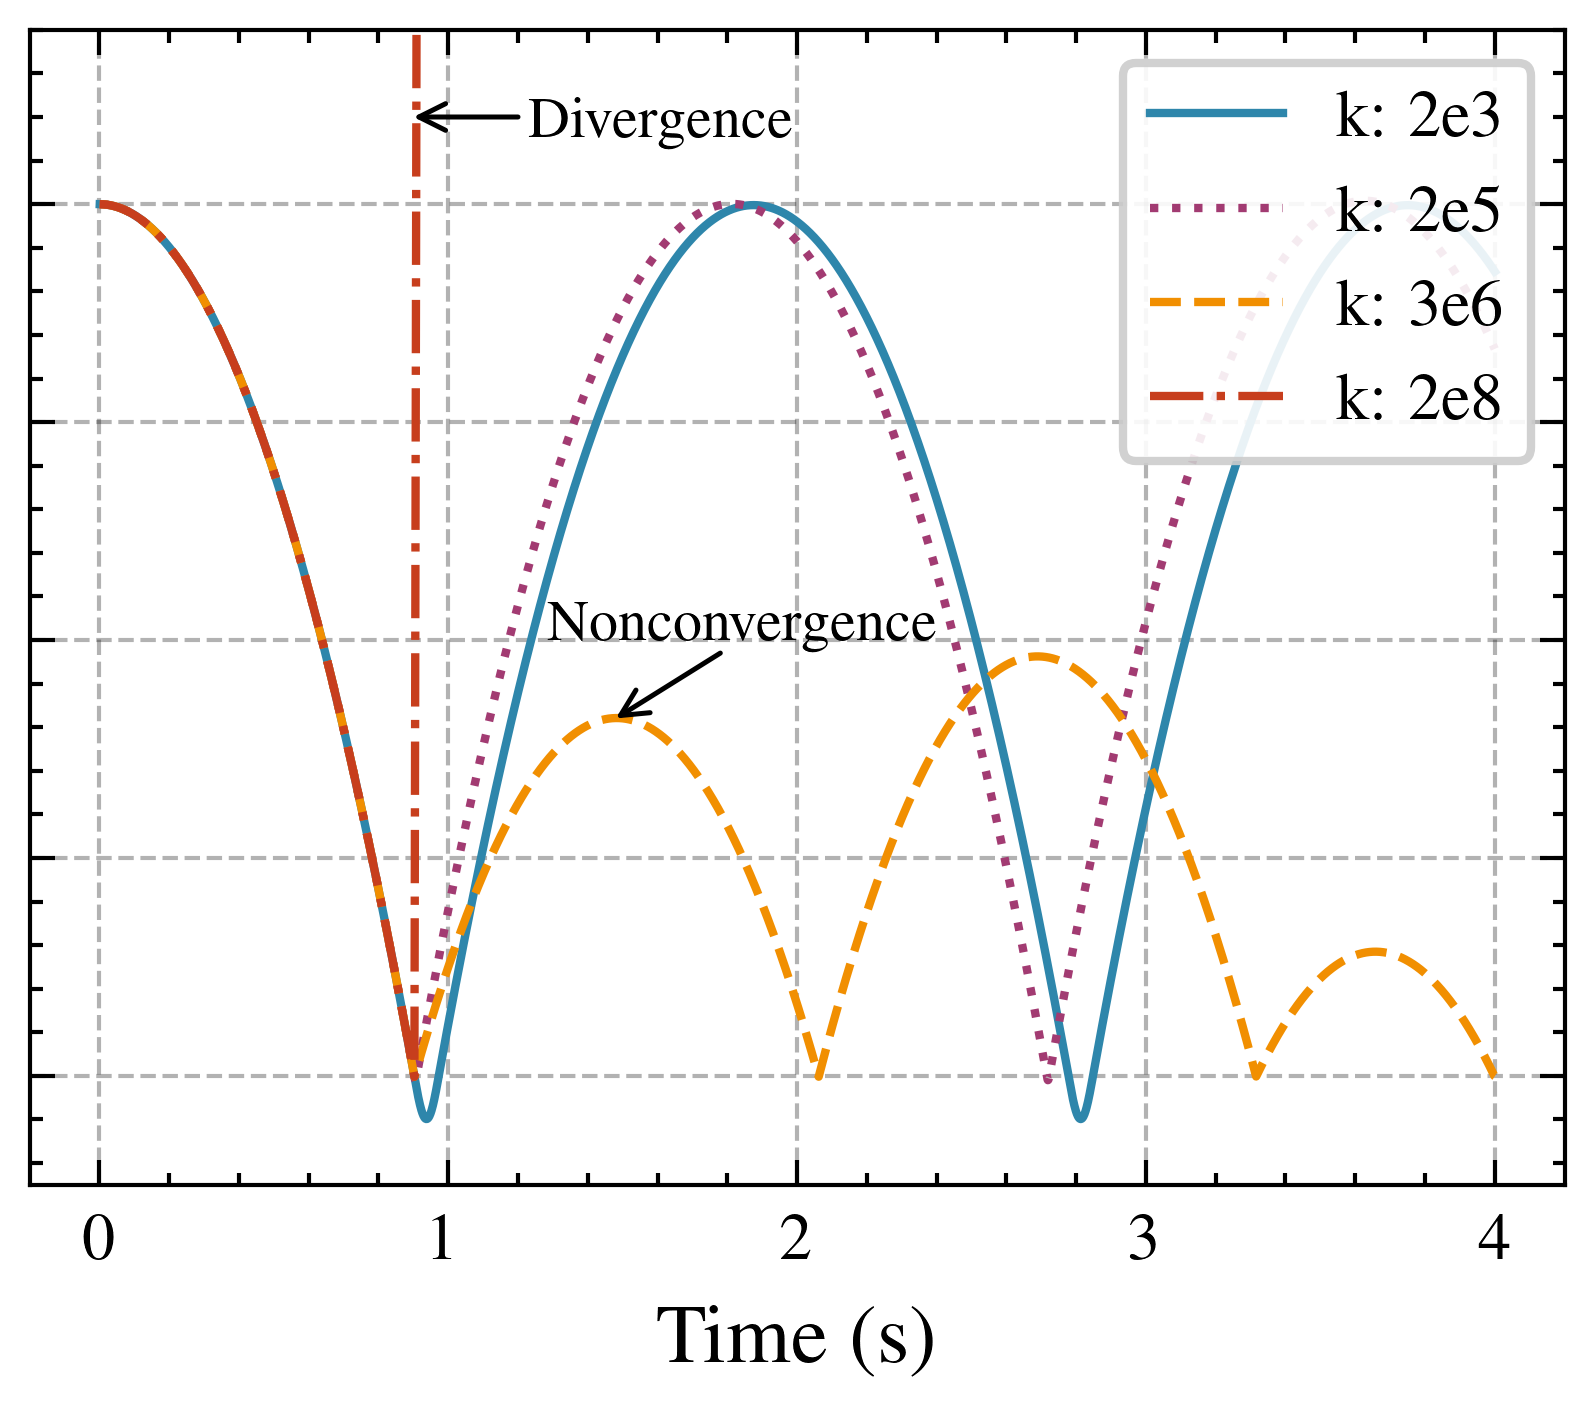

In [2]:
import matplotlib.pyplot as plt
import scienceplots  # 需要安装：pip install SciencePlots

# 指定支持扩展字符的字体
plt.rcParams['font.sans-serif'] = 'Microsoft YaHei'  # 或 'Source Han Sans', 'BabelStone Han'

# 使用科学论文风格绘制结果
with plt.style.context(['science', 'ieee', 'grid']):
    # 专业配色
    # linestyles = ["-", ":", "--"]
    linestyles = ["-", ":", "--", "-."]
    scientific_colors = [
        '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
        '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
    ]
    
    for i, result in enumerate(all_results[:]):
        time = result['time']
        height = result['height']
        solref = result['solref']
        # mask = height <= 5.0
        # filtered_time = time[mask]
        # filtered_height = height[mask]
        # 提取solref数值用于图例
        solref_value = solref.split()[0]
        
        # 绘制高度曲线
        plt.plot(time, height, linewidth=1, 
                label=f"k: {solref_value[1:]}", 
                color=scientific_colors[i], linestyle=linestyles[i % 4])
        linewidth = 0.6
        fontsize = 7
        if i == 3:
            # 选择连接点（椭圆上的点）
            connector_x = 0.9
            connector_y = 4.4

            # 文本位置
            text_x = connector_x + 0.3
            text_y = connector_y

            # 绘制连接线
            plt.annotate(
                '', 
                xy=(connector_x, connector_y), 
                xytext=(text_x, text_y),
                arrowprops=dict(
                    arrowstyle='->',
                    color="black",
                    lw=linewidth,
                    shrinkA=0,
                    shrinkB=0
                )
            )

            # 添加解释文本
            plt.text(
                text_x + 0.03, text_y - 0.03, 
                'Divergence',
                fontsize=fontsize,
                # bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7),
                verticalalignment='center',
                horizontalalignment='left'
            )
        if i == 2:
            # 选择连接点（椭圆上的点）
            connector_x = 1.48
            connector_y = 1.64

            # 文本位置
            text_x = connector_x + 0.3
            text_y = connector_y + 0.3

            # 绘制连接线
            plt.annotate(
                '', 
                xy=(connector_x, connector_y), 
                xytext=(text_x, text_y),
                arrowprops=dict(
                    arrowstyle='->',
                    color="black",
                    lw=linewidth,
                    shrinkA=0,
                    shrinkB=0
                )
            )

            # 添加解释文本
            plt.text(
                text_x + 0.06, text_y, 
                'Nonconvergence',
                fontsize=fontsize,
                # bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7),
                verticalalignment='bottom',
                horizontalalignment='center'
            )
    
    plt.legend(framealpha=0.9, loc="upper right")
    plt.xlabel(r'Time (s)', fontsize=10)
    plt.gca().set_yticklabels([])
    plt.ylim(top=4.8, bottom=-0.5)
    plt.grid(True, alpha=0.3)
    # plt.tight_layout()
    plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_mujoco.pdf", format="pdf", dpi=600, bbox_inches='tight')
    plt.show()


In [48]:
import mujoco
import numpy as np

# 定义不同的 solref 参数
solref_parameters = [
    "-2e8 -0",  # 原始参数
    "-2e8 -2e3",   # 中等刚度
    "-2e8 -5e3",   # 中等刚度
    "-2e8 -1e4",   # 中等刚度
    "-2e8 -1e5"    # 较低刚度
]

# 存储所有仿真结果
all_results = []

# 运行三次不同参数的仿真
for param_idx, solref in enumerate(solref_parameters):
    print(f"运行仿真 {param_idx+1}, solref={solref}")
    
    # MuJoCo模型XML字符串，使用当前参数
    MUJOCO_MODEL_XML = f"""
<mujoco>
  <option timestep="0.001"/>

  <default>
    <geom solref="{solref}"/>
  </default>
  
  <worldbody>
    <!-- 地面 -->
    <geom name="ground" type="plane" size="10 10 1" pos="0 0 0" rgba="0.8 0.9 0.8 1"/>
    
    <!-- 墙壁 -->
    <geom name="wall1" type="box" size="0.1 10 1" pos="-10 0 1" rgba="0.8 0.8 0.9 1"/>
    <geom name="wall2" type="box" size="0.1 10 1" pos="10 0 1" rgba="0.8 0.8 0.9 1"/>
    <geom name="wall3" type="box" size="10 0.1 1" pos="0 -10 1" rgba="0.8 0.8 0.9 1"/>
    <geom name="wall4" type="box" size="10 0.1 1" pos="0 10 1" rgba="0.8 0.8 0.9 1"/>
    
    <!-- 小球 -->
    <body name="ball" pos="0 0 4.5">
      <freejoint/>
      <geom name="ball_geom" type="sphere" size="0.5" rgba="0.9 0.2 0.2 1" mass="1"/>
    </body>
  </worldbody>
  
  <!-- 重力设置 -->
  <option gravity="0 0 -9.81"/>
</mujoco>
"""

    # 创建模型和仿真环境
    model = mujoco.MjModel.from_xml_string(MUJOCO_MODEL_XML)
    data = mujoco.MjData(model)

    # 设置仿真时长
    simulation_time = 4.0  # 仿真时间（秒）
    num_steps = int(simulation_time / model.opt.timestep)

    # 存储时间和高度数据
    time_points = np.zeros(num_steps)
    height_points = np.zeros(num_steps)
    velocity_points = np.zeros(num_steps)

    # 运行仿真
    for i in range(num_steps):
        # 执行仿真步骤
        mujoco.mj_step(model, data)
        
        # 记录时间、高度和速度
        time_points[i] = data.time
        height_points[i] = data.qpos[2] - 0.5  # z坐标
        velocity_points[i] = data.qvel[2]  # z方向速度

    # 保存结果
    result = {
        'time': time_points,
        'height': height_points,
        'velocity': velocity_points,
        'solref': solref
    }
    all_results.append(result)
    
    print(f"仿真 {param_idx+1} 完成")


运行仿真 1, solref=-2e8 -0
仿真 1 完成
运行仿真 2, solref=-2e8 -2e3
仿真 2 完成
运行仿真 3, solref=-2e8 -5e3
仿真 3 完成
运行仿真 4, solref=-2e8 -1e4
仿真 4 完成
运行仿真 5, solref=-2e8 -1e5
仿真 5 完成


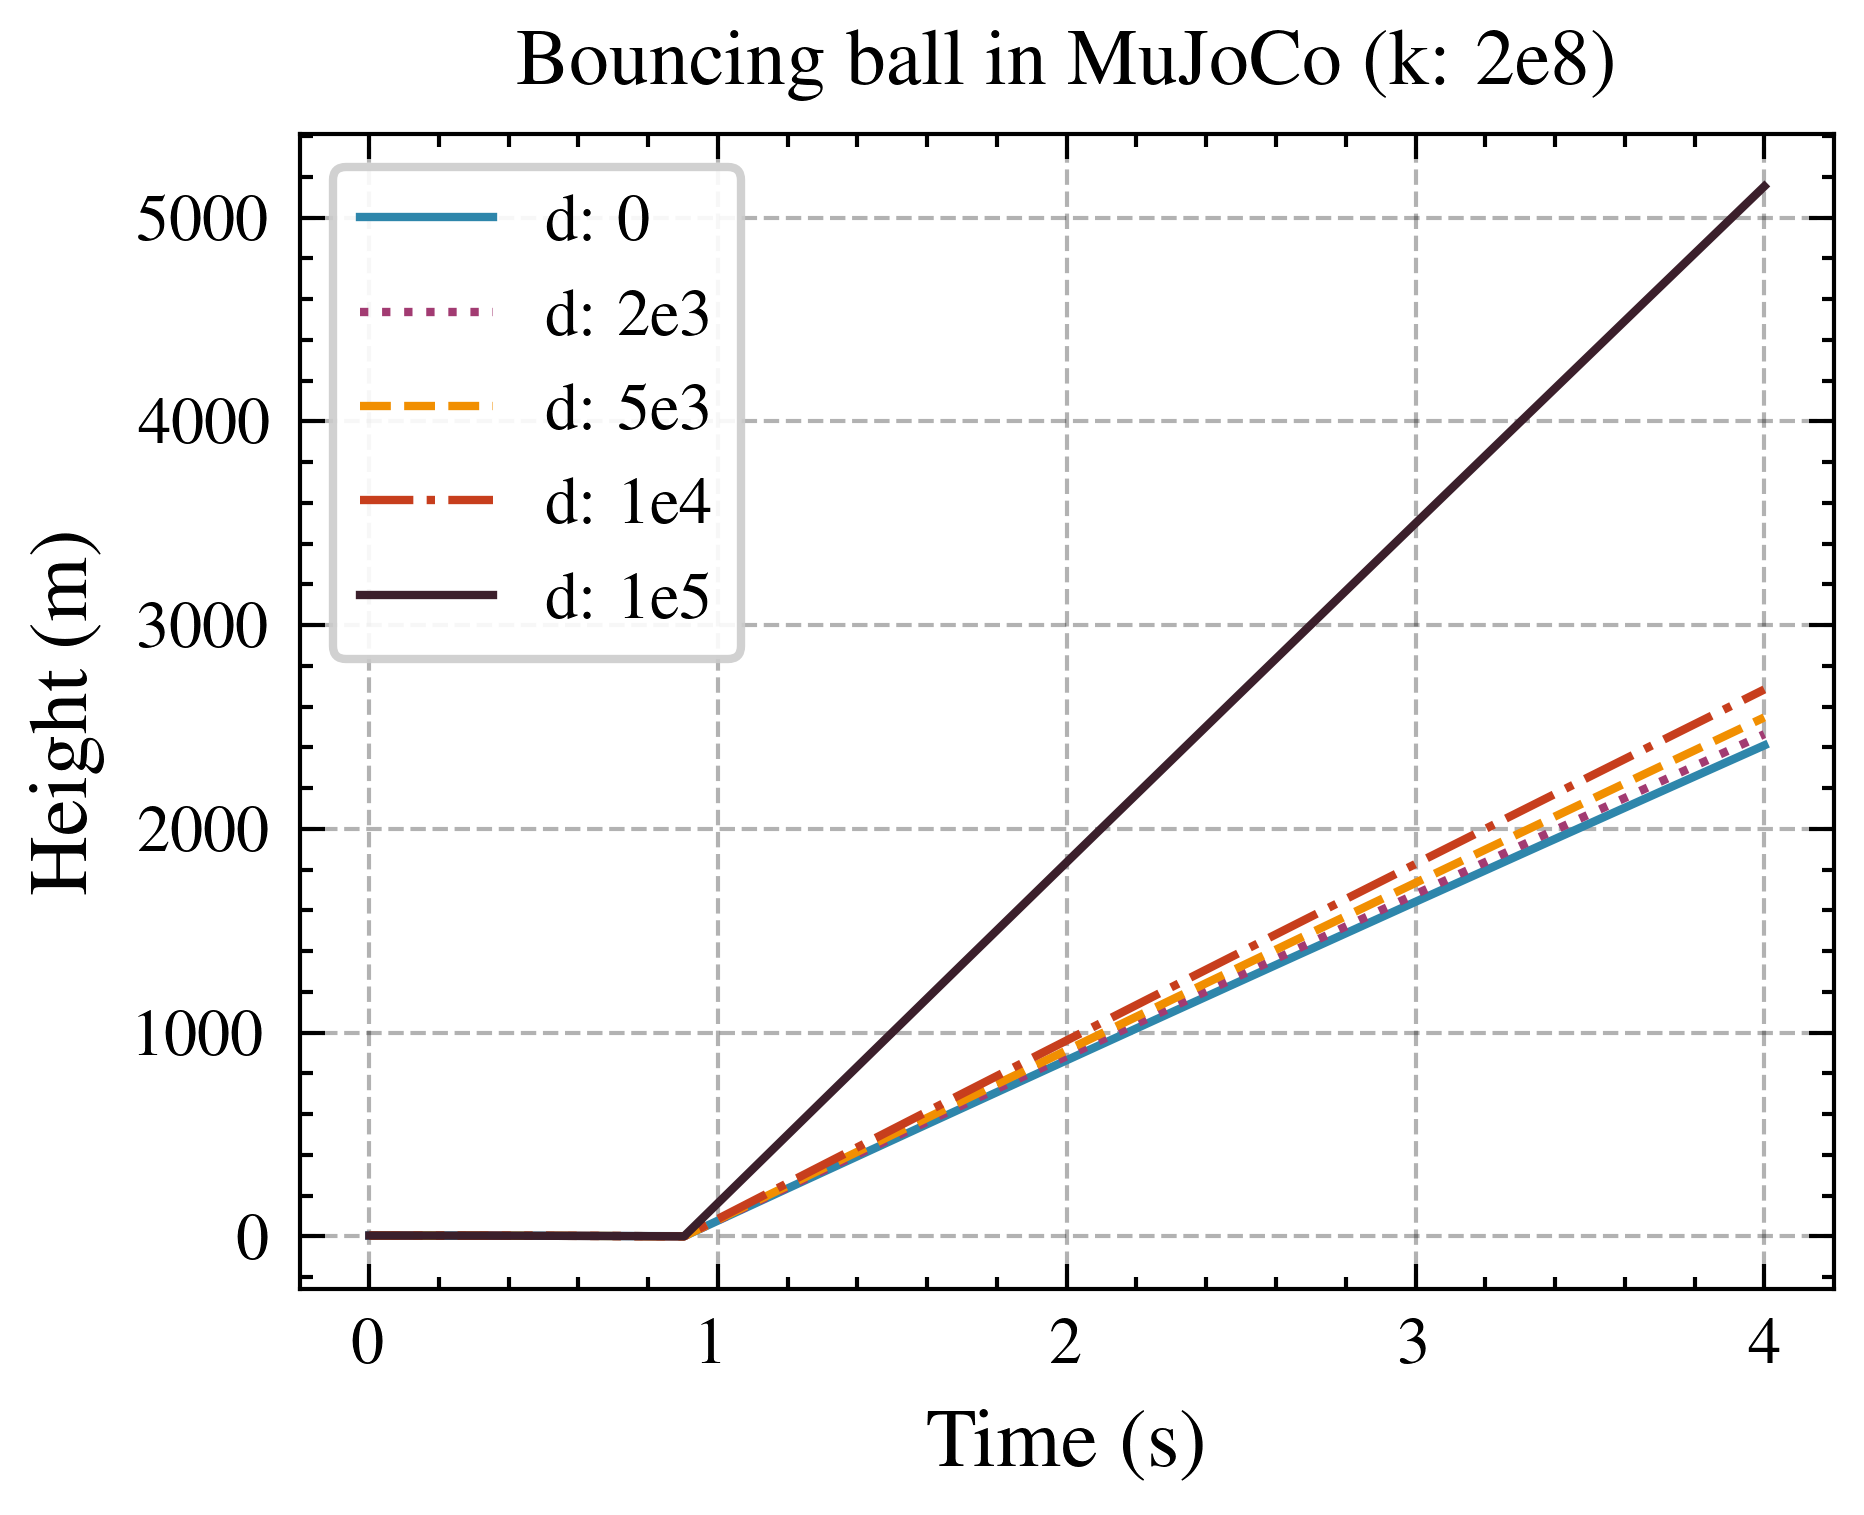

In [50]:
import matplotlib.pyplot as plt
import scienceplots  # 需要安装：pip install SciencePlots

# 指定支持扩展字符的字体
plt.rcParams['font.sans-serif'] = 'Microsoft YaHei'  # 或 'Source Han Sans', 'BabelStone Han'

# 使用科学论文风格绘制结果
with plt.style.context(['science', 'ieee', 'grid']):
    # 专业配色
    # linestyles = ["-", ":", "--"]
    linestyles = ["-", ":", "--", "-."]
    scientific_colors = [
        '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
        '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
    ]
    
    for i, result in enumerate(all_results[:]):
        time = result['time']
        height = result['height']
        solref = result['solref']
        # mask = height <= 5.0
        # filtered_time = time[mask]
        # filtered_height = height[mask]
        # 提取solref数值用于图例
        solref_value = solref.split()[1]
        
        # 绘制高度曲线
        plt.plot(time, height, linewidth=1, 
                label=f"d: {solref_value[1:]}", 
                color=scientific_colors[i], linestyle=linestyles[i % 4])
        linewidth = 0.6
        fontsize = 7

    plt.legend(framealpha=0.9, loc="best")
    plt.xlabel(r'Time (s)', fontsize=10)
    plt.ylabel(r'Height (m)', fontsize=10)
    plt.title('Bouncing ball in MuJoCo (k: 2e8)')
    # plt.gca().set_yticklabels([]) 
    # plt.ylim(top=4.8, bottom=-0.5)
    plt.grid(True, alpha=0.3)
    # plt.tight_layout()
    # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_mujoco.pdf", format="pdf", dpi=600, bbox_inches='tight')
    plt.show()


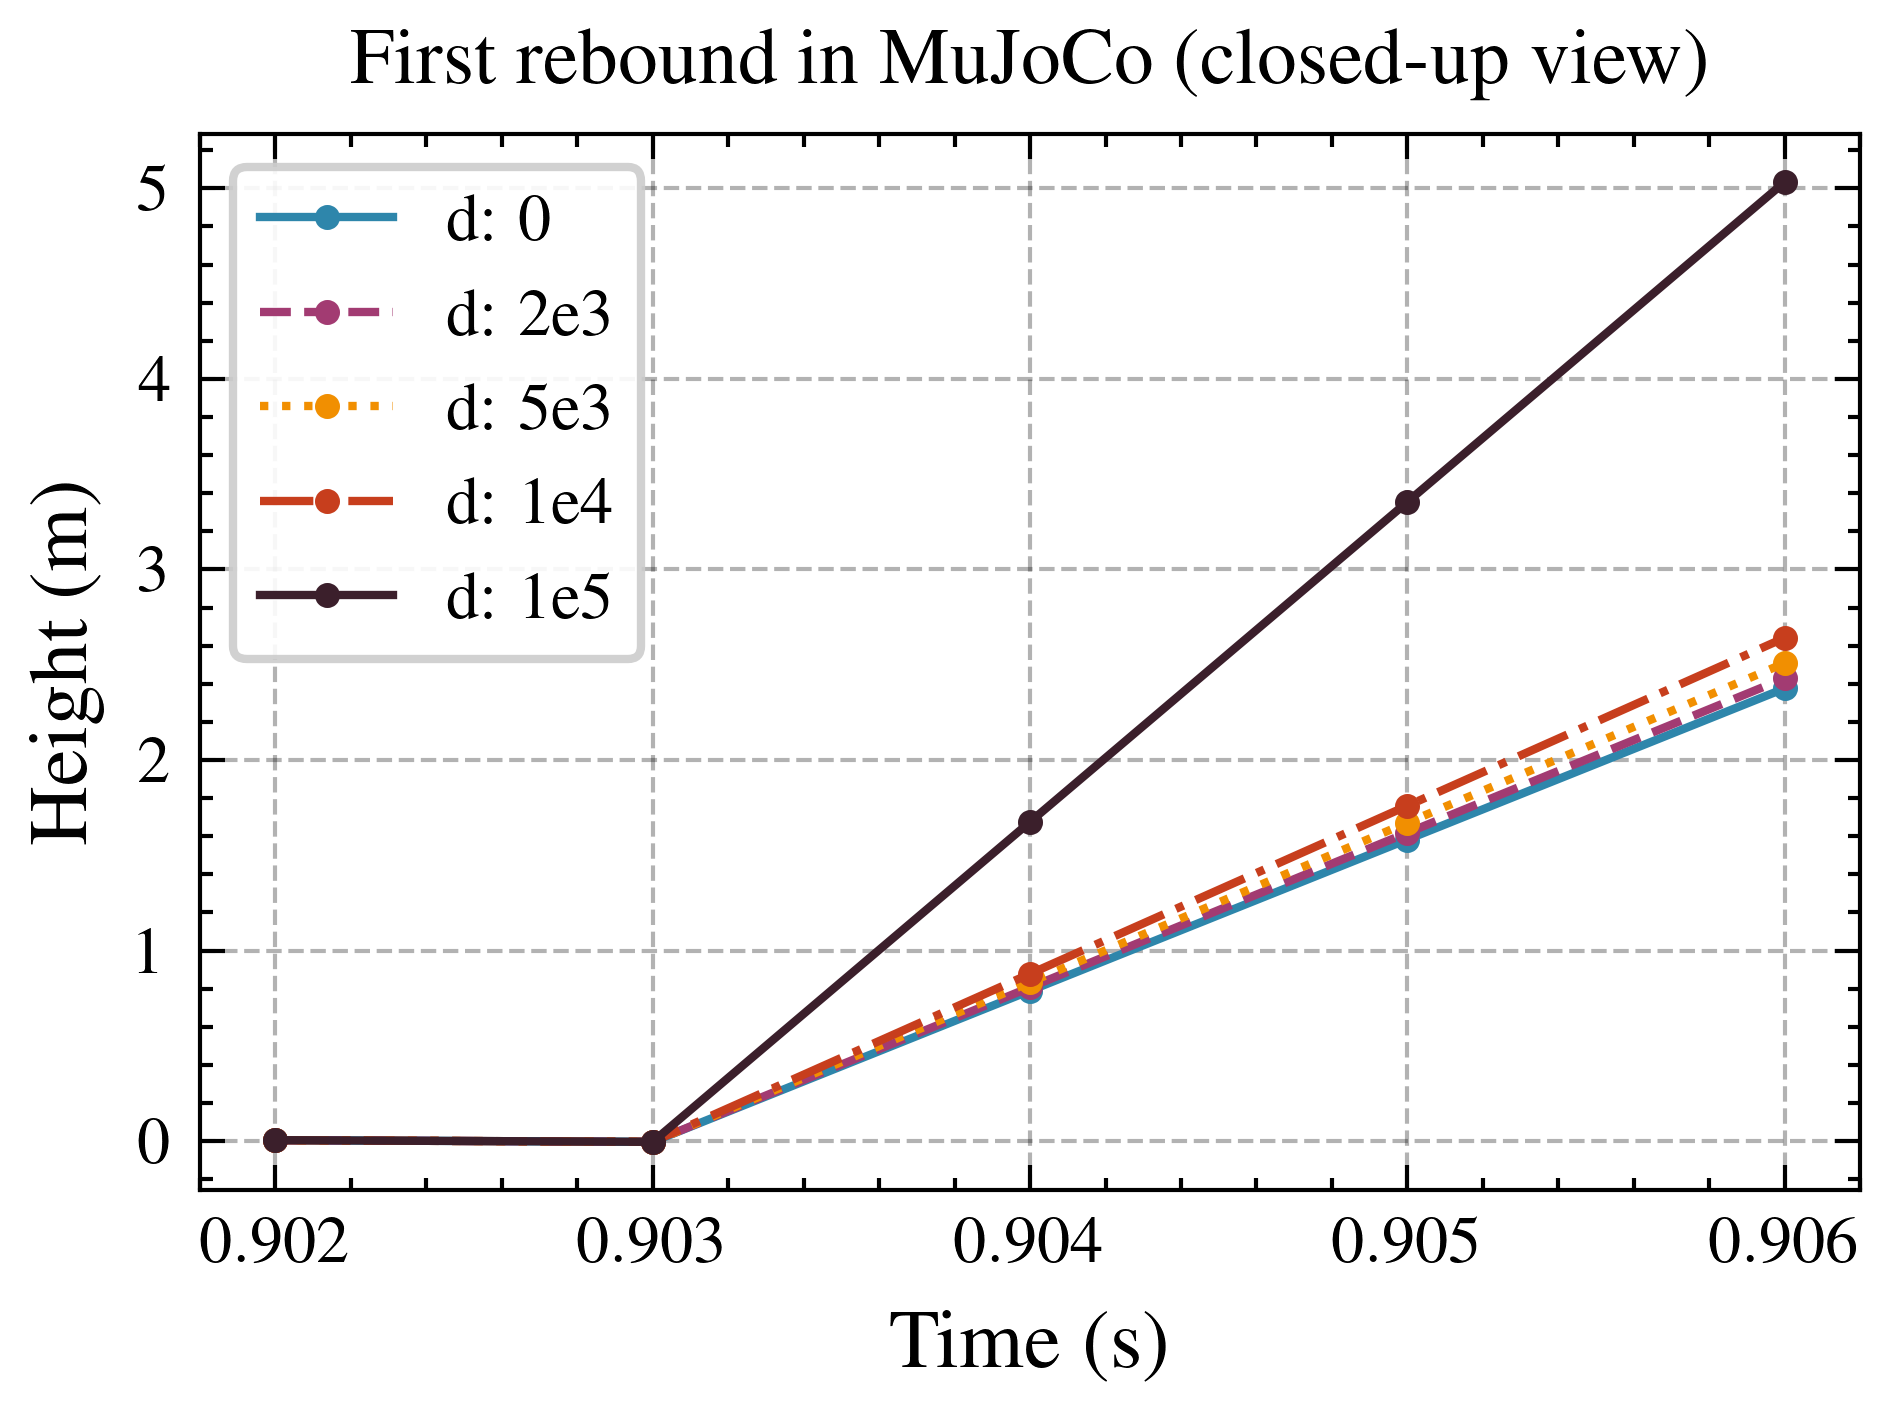

In [51]:
# 使用科学论文风格绘制结果
with plt.style.context(['science', 'ieee', 'grid']):
    # 专业配色
    # linestyles = ["-", ":", "--"]
    linestyles = ["-","--", ":"]
    scientific_colors = [
        '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
        '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
    ]
    
    for i, result in enumerate(all_results[:]):
        time = result['time']
        height = result['height']
        solref = result['solref']
        mask1 = time >= 0.902
        mask2 = time <= 0.906 + 1e-6
        combined_mask = mask1 & mask2 
        filtered_time = time[combined_mask]
        filtered_height = height[combined_mask]
        # 提取solref数值用于图例
        solref_value = solref.split()[1]
        # 绘制高度曲线
        plt.plot(filtered_time, filtered_height, 
                 marker='o', markersize=2,
                label=f"d: {solref_value[1:]}", 
                color=scientific_colors[i])

    plt.ylabel(r'Height (m)', fontsize=10)
    plt.xlabel(r'Time (s)', fontsize=10)
    plt.legend(framealpha=0.9, loc="best")
    # plt.ylim(top=7, bottom=-0.3)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.title('First rebound in MuJoCo (closed-up view)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    # plt.savefig("sphere_free_fall_height_mujoco.pdf", format="pdf")
    # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_mujoco.pdf", format="pdf")
    plt.show()

In [45]:
import mujoco
import numpy as np

# 定义不同的 solref 参数
solref_parameters = [
    "-2e4 0",  # 原始参数
    "-2e5 0",   # 中等刚度
    # "-2e6 0",   # 中等刚度
    # "-3e6 0",   # 中等刚度
    # "-2e8 0"    # 较低刚度
]

# 存储所有仿真结果
all_results = []

# 运行三次不同参数的仿真
for param_idx, solref in enumerate(solref_parameters):
    print(f"运行仿真 {param_idx+1}, solref={solref}")
    
    # MuJoCo模型XML字符串，使用当前参数
    MUJOCO_MODEL_XML = f"""
<mujoco>
  <option timestep="0.001"/>

  <default>
    <geom solref="{solref}"/>
  </default>
  
  <worldbody>
    <!-- 地面 -->
    <geom name="ground" type="plane" size="10 10 1" pos="0 0 0" rgba="0.8 0.9 0.8 1"/>
    
    <!-- 墙壁 -->
    <geom name="wall1" type="box" size="0.1 10 1" pos="-10 0 1" rgba="0.8 0.8 0.9 1"/>
    <geom name="wall2" type="box" size="0.1 10 1" pos="10 0 1" rgba="0.8 0.8 0.9 1"/>
    <geom name="wall3" type="box" size="10 0.1 1" pos="0 -10 1" rgba="0.8 0.8 0.9 1"/>
    <geom name="wall4" type="box" size="10 0.1 1" pos="0 10 1" rgba="0.8 0.8 0.9 1"/>
    
    <!-- 小球 -->
    <body name="ball" pos="0 0 4.5">
      <freejoint/>
      <geom name="ball_geom" type="sphere" size="0.5" rgba="0.9 0.2 0.2 1" mass="1"/>
    </body>
  </worldbody>
  
  <!-- 重力设置 -->
  <option gravity="0 0 -9.81"/>
</mujoco>
"""

    # 创建模型和仿真环境
    model = mujoco.MjModel.from_xml_string(MUJOCO_MODEL_XML)
    data = mujoco.MjData(model)

    # 设置仿真时长
    simulation_time = 4.0  # 仿真时间（秒）
    num_steps = int(simulation_time / model.opt.timestep)

    # 存储时间和高度数据
    time_points = np.zeros(num_steps)
    height_points = np.zeros(num_steps)
    velocity_points = np.zeros(num_steps)

    # 运行仿真
    for i in range(num_steps):
        # 执行仿真步骤
        mujoco.mj_step(model, data)
        
        # 记录时间、高度和速度
        time_points[i] = data.time
        height_points[i] = data.qpos[2] - 0.5  # z坐标
        velocity_points[i] = data.qvel[2]  # z方向速度

    # 保存结果
    result = {
        'time': time_points,
        'height': height_points,
        'velocity': velocity_points,
        'solref': solref
    }
    all_results.append(result)
    
    print(f"仿真 {param_idx+1} 完成")


运行仿真 1, solref=-2e4 0
仿真 1 完成
运行仿真 2, solref=-2e5 0
仿真 2 完成


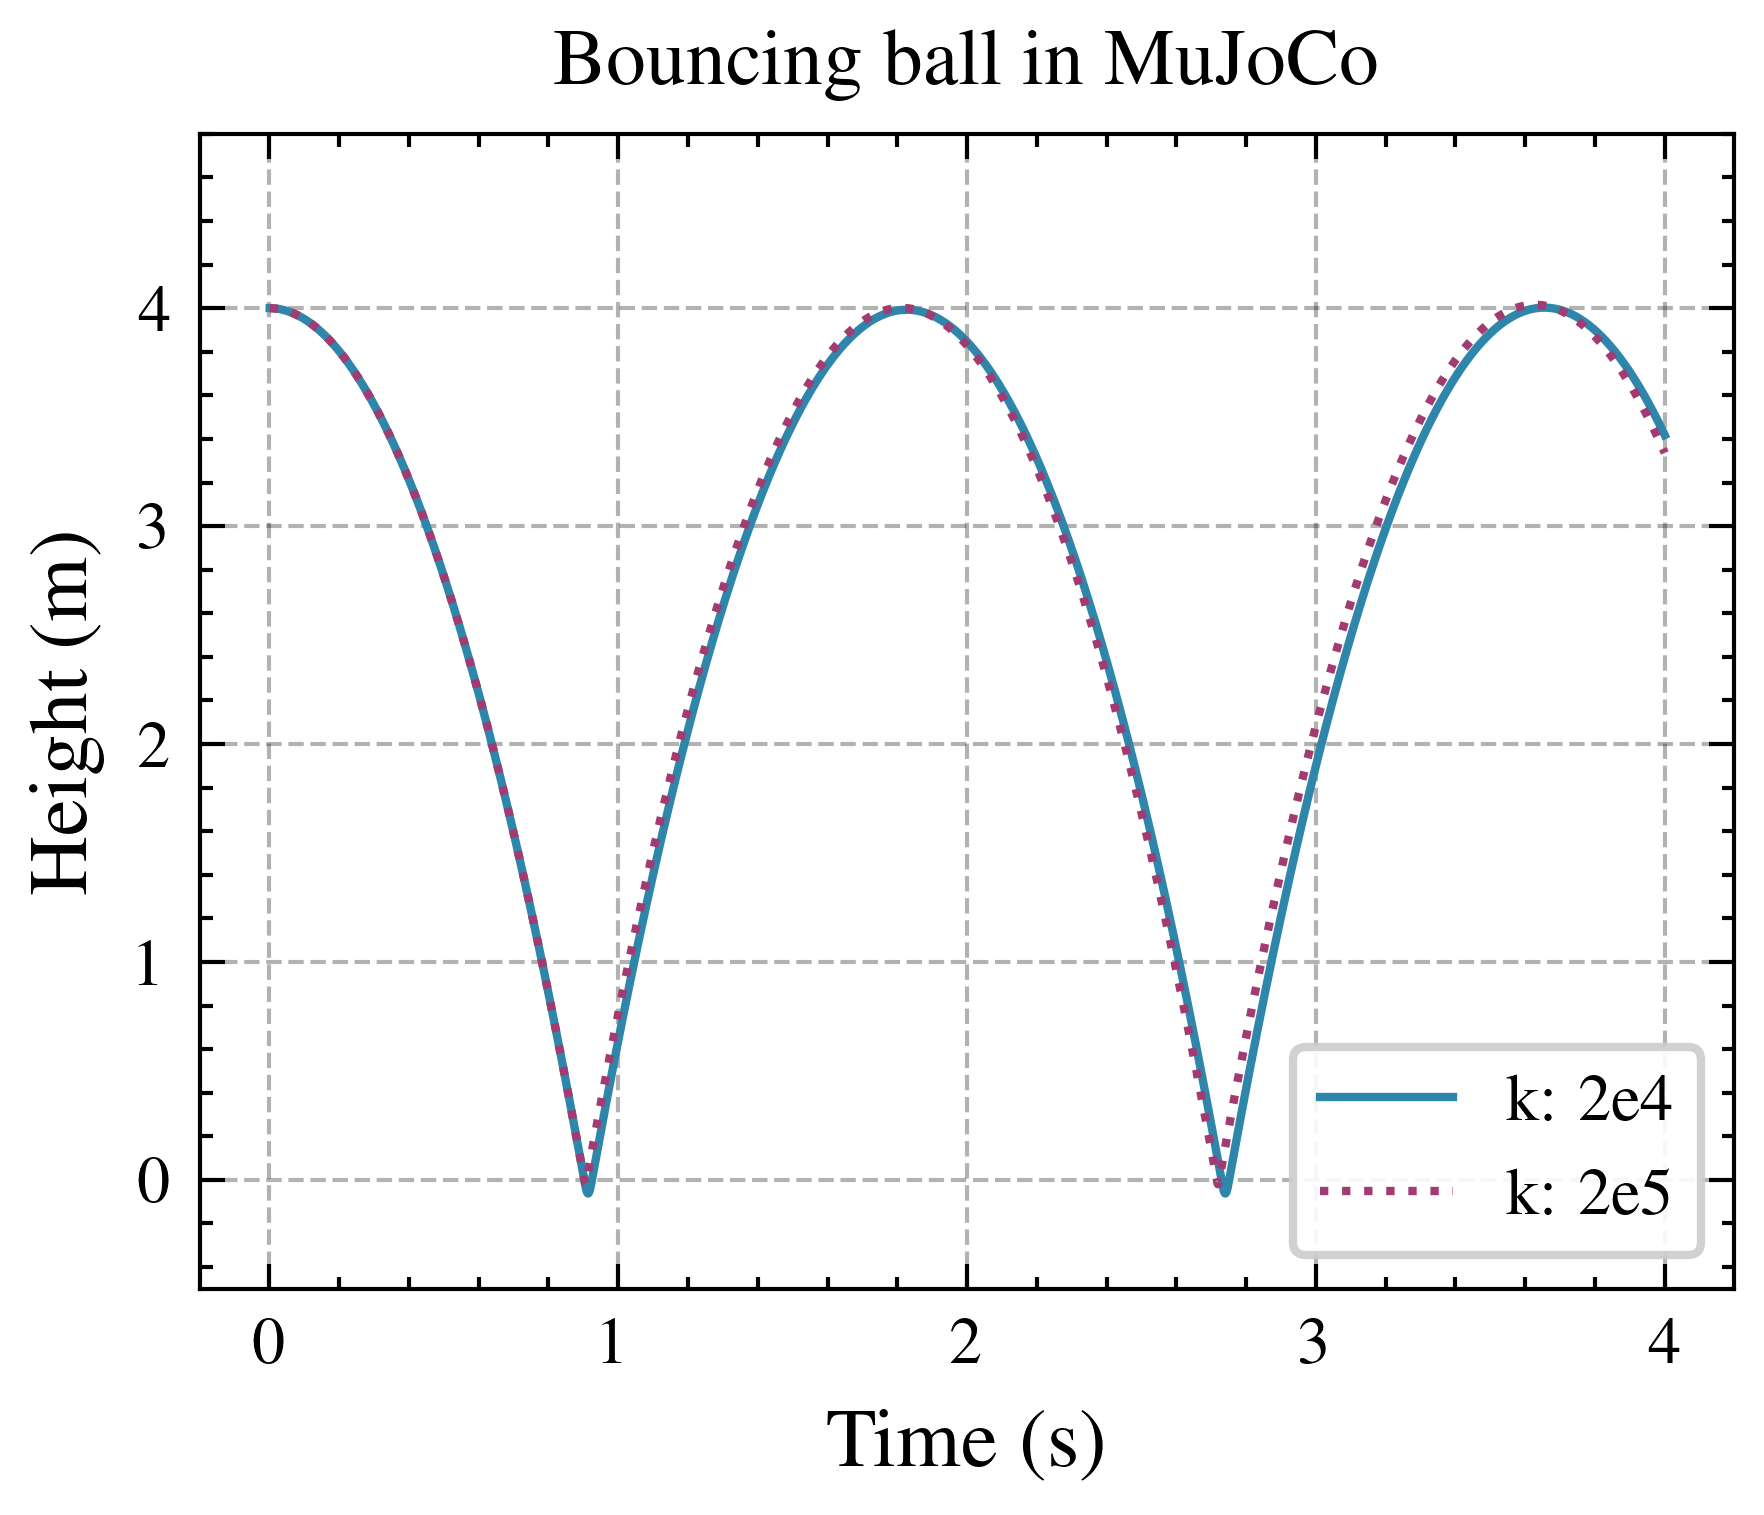

In [46]:
import matplotlib.pyplot as plt
import scienceplots  # 需要安装：pip install SciencePlots

# 指定支持扩展字符的字体
plt.rcParams['font.sans-serif'] = 'Microsoft YaHei'  # 或 'Source Han Sans', 'BabelStone Han'

# 使用科学论文风格绘制结果
with plt.style.context(['science', 'ieee', 'grid']):
    # 专业配色
    # linestyles = ["-", ":", "--"]
    linestyles = ["-", ":", "--", "-."]
    scientific_colors = [
        '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
        '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
    ]
    
    for i, result in enumerate(all_results[:]):
        time = result['time']
        height = result['height']
        solref = result['solref']
        # mask = height <= 5.0
        # filtered_time = time[mask]
        # filtered_height = height[mask]
        # 提取solref数值用于图例
        solref_value = solref.split()[0]
        
        # 绘制高度曲线
        plt.plot(time, height, linewidth=1, 
                label=f"k: {solref_value[1:]}", 
                color=scientific_colors[i], linestyle=linestyles[i % 4])
        linewidth = 0.6
        fontsize = 7

    plt.legend(framealpha=0.9, loc="best")
    plt.xlabel(r'Time (s)', fontsize=10)
    plt.ylabel(r'Height (m)', fontsize=10)
    plt.title('Bouncing ball in MuJoCo')
    # plt.gca().set_yticklabels([]) 
    plt.ylim(top=4.8, bottom=-0.5)
    plt.grid(True, alpha=0.3)
    # plt.tight_layout()
    # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_mujoco.pdf", format="pdf", dpi=600, bbox_inches='tight')
    plt.show()
    plt.close()

    for i, result in enumerate(all_results[:]):
        time = result['time']
        height = result['height']
        solref = result['solref']
        # mask = height <= 5.0
        # filtered_time = time[mask]
        # filtered_height = height[mask]
        # 提取solref数值用于图例
        solref_value = solref.split()[0]
        
        # 绘制高度曲线
        plt.plot(time, height, linewidth=1, 
                label=f"k: {solref_value[1:]}", 
                color=scientific_colors[i], linestyle=linestyles[i % 4])
        linewidth = 0.6
        fontsize = 7

    plt.legend(framealpha=0.9, loc="best")
    plt.xlabel(r'Time (s)', fontsize=10)
    plt.ylabel(r'Height (m)', fontsize=10)
    # plt.title('Bouncing ball in MuJoCo')
    # plt.gca().set_yticklabels([]) 
    plt.ylim(top=4.8, bottom=-0.5)
    plt.grid(True, alpha=0.3)
    # plt.tight_layout()
    plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_mujoco_soft.pdf", format="pdf", dpi=600, bbox_inches='tight')
    plt.close()
    # plt.show()


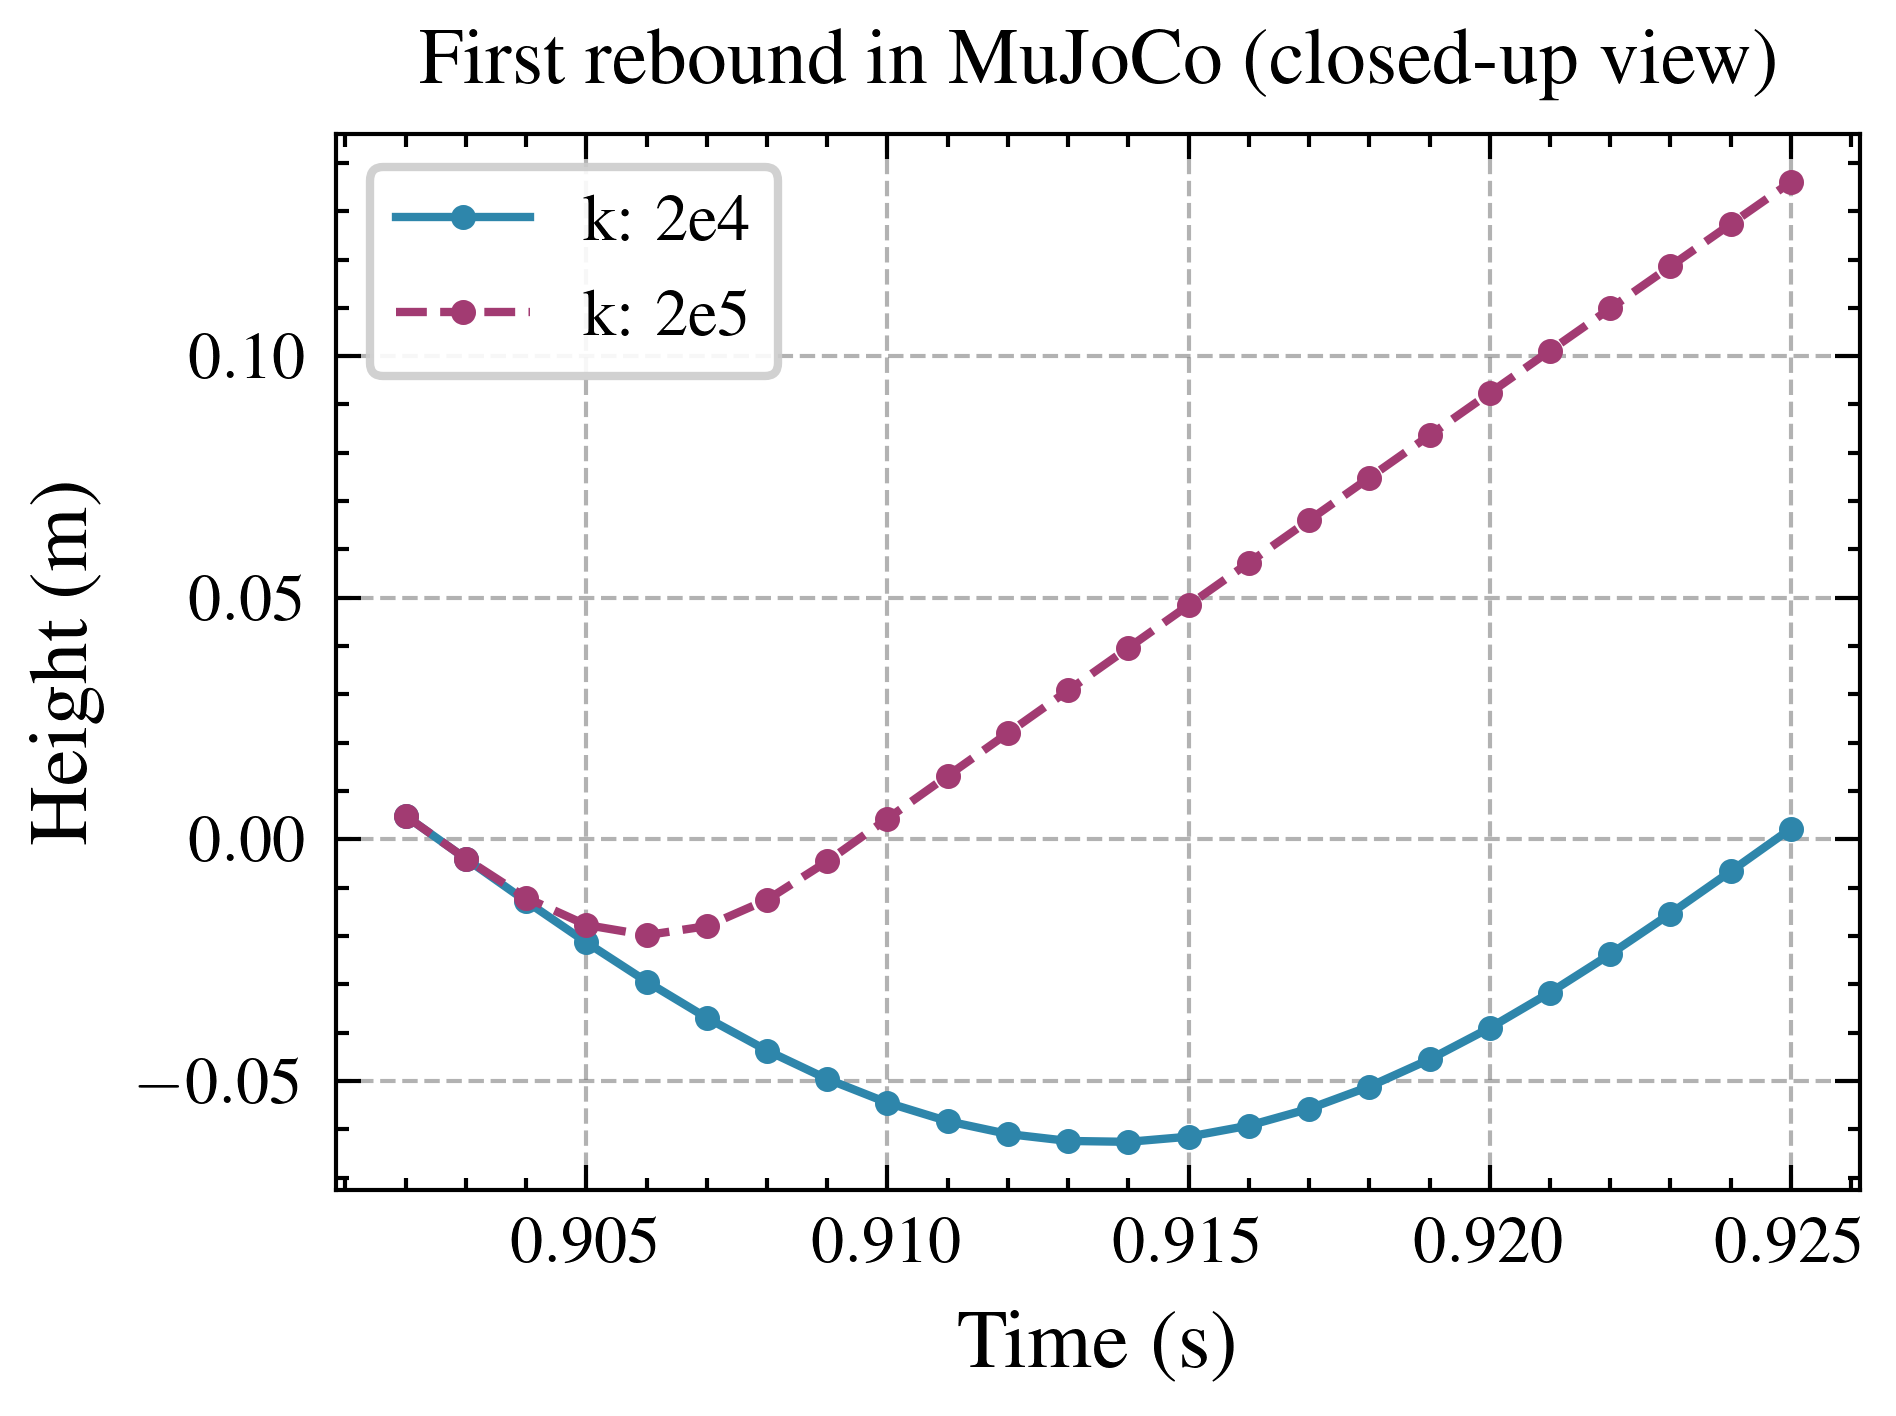

In [47]:
import matplotlib.pyplot as plt
import scienceplots  # 需要安装：pip install SciencePlots

# 指定支持扩展字符的字体
plt.rcParams['font.sans-serif'] = 'Microsoft YaHei'  # 或 'Source Han Sans', 'BabelStone Han'

# 使用科学论文风格绘制结果
with plt.style.context(['science', 'ieee', 'grid']):
    # 专业配色
    # linestyles = ["-", ":", "--"]
    linestyles = ["-","--", ":"]
    scientific_colors = [
        '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
        '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
    ]
    
    for i, result in enumerate(all_results[:]):
        time = result['time']
        height = result['height']
        solref = result['solref']
        mask1 = time >= 0.902
        mask2 = time <= 0.925 + 1e-6
        combined_mask = mask1 & mask2 
        filtered_time = time[combined_mask]
        filtered_height = height[combined_mask]
        # 提取solref数值用于图例
        solref_value = solref.split()[0]
        # 绘制高度曲线
        plt.plot(filtered_time, filtered_height, 
                 marker='o', markersize=2,
                label=f"k: {solref_value[1:]}", 
                color=scientific_colors[i])

    plt.ylabel(r'Height (m)', fontsize=10)
    plt.xlabel(r'Time (s)', fontsize=10)
    plt.legend(framealpha=0.9, loc="best")
    # plt.ylim(top=7, bottom=-0.3)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.title('First rebound in MuJoCo (closed-up view)')
    plt.tight_layout()
    # plt.savefig("sphere_free_fall_height_mujoco.pdf", format="pdf")
    # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_mujoco.pdf", format="pdf")
    plt.show()
    plt.close()

    for i, result in enumerate(all_results[:]):
        time = result['time']
        height = result['height']
        solref = result['solref']
        mask1 = time >= 0.902
        mask2 = time <= 0.925 + 1e-6
        combined_mask = mask1 & mask2 
        filtered_time = time[combined_mask]
        filtered_height = height[combined_mask]
        # 提取solref数值用于图例
        solref_value = solref.split()[0]
        # 绘制高度曲线
        plt.plot(filtered_time, filtered_height, 
                 marker='o', markersize=2,
                label=f"k: {solref_value[1:]}", 
                color=scientific_colors[i])

    plt.ylabel(r'Height (m)', fontsize=10)
    plt.xlabel(r'Time (s)', fontsize=10)
    plt.legend(framealpha=0.9, loc="best")
    # plt.ylim(top=7, bottom=-0.3)
    plt.grid(True, linestyle='--', alpha=0.3)
    # plt.title('First rebound in MuJoCo (closed-up view)')
    plt.tight_layout()
    # plt.savefig("sphere_free_fall_height_mujoco.pdf", format="pdf")
    plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_mujoco_soft_zoomed.pdf", format="pdf")
    # plt.show()

## Performance Tests

### Duration 10s simulation profile without dissipation.

In [12]:
import mujoco
import numpy as np
import time
# 定义不同的 solref 参数
solref_parameters = [
    "-2e3 0",  # 原始参数
    "-2e5 0",   # 中等刚度
    # "-2e6 0",   # 中等刚度
    "-3e6 0",   # 中等刚度
    "-2e8 0"    # 较低刚度
]

# 存储所有仿真结果
n = 40
timeCostResult = np.zeros([len(solref_parameters), n])
# 运行三次不同参数的仿真
for param_idx, solref in enumerate(solref_parameters):
    print(f"运行仿真 {param_idx+1}, solref={solref}")
    for j in range(n):
    # MuJoCo模型XML字符串，使用当前参数
      MUJOCO_MODEL_XML = f"""
<mujoco>
  <option timestep="0.001"/>

  <default>
    <geom solref="{solref}"/>
  </default>
  
  <worldbody>
    <!-- 地面 -->
    <geom name="ground" type="plane" size="10 10 1" pos="0 0 0" rgba="0.8 0.9 0.8 1"/>
    
    <!-- 墙壁 -->
    <geom name="wall1" type="box" size="0.1 10 1" pos="-10 0 1" rgba="0.8 0.8 0.9 1"/>
    <geom name="wall2" type="box" size="0.1 10 1" pos="10 0 1" rgba="0.8 0.8 0.9 1"/>
    <geom name="wall3" type="box" size="10 0.1 1" pos="0 -10 1" rgba="0.8 0.8 0.9 1"/>
    <geom name="wall4" type="box" size="10 0.1 1" pos="0 10 1" rgba="0.8 0.8 0.9 1"/>
    
    <!-- 小球 -->
    <body name="ball" pos="0 0 4.5">
      <freejoint/>
      <geom name="ball_geom" type="sphere" size="0.5" rgba="0.9 0.2 0.2 1" mass="1"/>
    </body>
  </worldbody>
  
  <!-- 重力设置 -->
  <option gravity="0 0 -9.81"/>
</mujoco>
"""

      # 创建模型和仿真环境
      model = mujoco.MjModel.from_xml_string(MUJOCO_MODEL_XML)
      data = mujoco.MjData(model)

      # 设置仿真时长
      simulation_time = 10.0  # 仿真时间（秒）
      num_steps = int(simulation_time / model.opt.timestep)

      # 存储时间和高度数据
      time_points = np.zeros(num_steps)
      height_points = np.zeros(num_steps)
      velocity_points = np.zeros(num_steps)

      start = time.perf_counter()
      # 运行仿真
      for i in range(num_steps):
          # 执行仿真步骤
          mujoco.mj_step(model, data)
      end = time.perf_counter()
      elapsed = end - start
      timeCostResult[param_idx][j] = elapsed
    print(f"仿真 {param_idx+1} 完成")
    
np.savetxt(
    'mujoco_perf_measure_10s_zero_dissipation.csv',          # Filename
    timeCostResult.transpose(),  # Combine x and y into two columns
    delimiter=',',            # Use comma as delimiter
    comments=''               # Remove '#' from header
)

运行仿真 1, solref=-2e3 0
仿真 1 完成
运行仿真 2, solref=-2e5 0
仿真 2 完成
运行仿真 3, solref=-3e6 0
仿真 3 完成
运行仿真 4, solref=-2e8 0
仿真 4 完成


In [13]:
# Read data from CSV using NumPy
data = np.genfromtxt('mujoco_perf_measure_10s_zero_dissipation.csv', delimiter=',')

print(np.sum(data, 0) / data.shape[0])


[0.02698413 0.0264584  0.0298377  0.0261456 ]


### Duration 10s simulation profile with high dissipation.

In [14]:
import mujoco
import numpy as np
import time
# 定义不同的 solref 参数
solref_parameters = [
    "-2e3 -1e5",  # 原始参数
    "-2e5 -1e5",   # 中等刚度
    # "-2e6 0",   # 中等刚度
    "-3e6 -1e5",   # 中等刚度
    "-2e8 -1e5"    # 较低刚度
]

# 存储所有仿真结果
n = 40
timeCostResult = np.zeros([len(solref_parameters), n])
# 运行三次不同参数的仿真
for param_idx, solref in enumerate(solref_parameters):
    print(f"运行仿真 {param_idx+1}, solref={solref}")
    for j in range(n):
    # MuJoCo模型XML字符串，使用当前参数
      MUJOCO_MODEL_XML = f"""
<mujoco>
  <option timestep="0.001"/>

  <default>
    <geom solref="{solref}"/>
  </default>
  
  <worldbody>
    <!-- 地面 -->
    <geom name="ground" type="plane" size="10 10 1" pos="0 0 0" rgba="0.8 0.9 0.8 1"/>
    
    <!-- 墙壁 -->
    <geom name="wall1" type="box" size="0.1 10 1" pos="-10 0 1" rgba="0.8 0.8 0.9 1"/>
    <geom name="wall2" type="box" size="0.1 10 1" pos="10 0 1" rgba="0.8 0.8 0.9 1"/>
    <geom name="wall3" type="box" size="10 0.1 1" pos="0 -10 1" rgba="0.8 0.8 0.9 1"/>
    <geom name="wall4" type="box" size="10 0.1 1" pos="0 10 1" rgba="0.8 0.8 0.9 1"/>
    
    <!-- 小球 -->
    <body name="ball" pos="0 0 4.5">
      <freejoint/>
      <geom name="ball_geom" type="sphere" size="0.5" rgba="0.9 0.2 0.2 1" mass="1"/>
    </body>
  </worldbody>
  
  <!-- 重力设置 -->
  <option gravity="0 0 -9.81"/>
</mujoco>
"""

      # 创建模型和仿真环境
      model = mujoco.MjModel.from_xml_string(MUJOCO_MODEL_XML)
      data = mujoco.MjData(model)

      # 设置仿真时长
      simulation_time = 10.0  # 仿真时间（秒）
      num_steps = int(simulation_time / model.opt.timestep)

      # 存储时间和高度数据
      time_points = np.zeros(num_steps)
      height_points = np.zeros(num_steps)
      velocity_points = np.zeros(num_steps)

      start = time.perf_counter()
      # 运行仿真
      for i in range(num_steps):
          # 执行仿真步骤
          mujoco.mj_step(model, data)
      end = time.perf_counter()
      elapsed = end - start
      timeCostResult[param_idx][j] = elapsed
    print(f"仿真 {param_idx+1} 完成")
    
np.savetxt(
    'mujoco_perf_measure_10s_high_dissipation.csv',          # Filename
    timeCostResult.transpose(),  # Combine x and y into two columns
    delimiter=',',            # Use comma as delimiter
    comments=''               # Remove '#' from header
)

运行仿真 1, solref=-2e3 -1e5
仿真 1 完成
运行仿真 2, solref=-2e5 -1e5
仿真 2 完成
运行仿真 3, solref=-3e6 -1e5
仿真 3 完成
运行仿真 4, solref=-2e8 -1e5
仿真 4 完成


In [ ]:
# Read data from CSV using NumPy
data = np.genfromtxt('mujoco_perf_measure_10s_high_dissipation.csv', delimiter=',')

print(np.sum(data, 0) / data.shape[0])


[0.02533467 0.02472246 0.0251807  0.02672652]


### Contact profile

In [ ]:
import mujoco
import numpy as np
import time
# 定义不同的 solref 参数
solref_parameters = [
    "-2e3 0",  # 原始参数
    "-2e5 0",   # 中等刚度
    # "-2e6 0",   # 中等刚度
    "-3e6 0",   # 中等刚度
    "-2e8 0"    # 较低刚度
]

# 存储所有仿真结果
n = 1000
timeCostResult = np.zeros([len(solref_parameters), n])
# 运行三次不同参数的仿真
for param_idx, solref in enumerate(solref_parameters):
    print(f"运行仿真 {param_idx+1}, solref={solref}")
    for j in range(n):
    # MuJoCo模型XML字符串，使用当前参数
      MUJOCO_MODEL_XML = f"""
<mujoco>
  <option timestep="0.001"/>

  <default>
    <geom solref="{solref}"/>
  </default>
  
  <worldbody>
    <!-- 地面 -->
    <geom name="ground" type="plane" size="10 10 1" pos="0 0 0" rgba="0.8 0.9 0.8 1"/>
    
    <!-- 墙壁 -->
    <geom name="wall1" type="box" size="0.1 10 1" pos="-10 0 1" rgba="0.8 0.8 0.9 1"/>
    <geom name="wall2" type="box" size="0.1 10 1" pos="10 0 1" rgba="0.8 0.8 0.9 1"/>
    <geom name="wall3" type="box" size="10 0.1 1" pos="0 -10 1" rgba="0.8 0.8 0.9 1"/>
    <geom name="wall4" type="box" size="10 0.1 1" pos="0 10 1" rgba="0.8 0.8 0.9 1"/>
    
    <!-- 小球 -->
    <body name="ball" pos="0 0 4.5">
      <freejoint/>
      <geom name="ball_geom" type="sphere" size="0.5" rgba="0.9 0.2 0.2 1" mass="1"/>
    </body>
  </worldbody>
  
  <!-- 重力设置 -->
  <option gravity="0 0 -9.81"/>
</mujoco>
"""

      # 创建模型和仿真环境
      model = mujoco.MjModel.from_xml_string(MUJOCO_MODEL_XML)
      data = mujoco.MjData(model)
      data.qpos[2] = 0.4912119999999864
      data.qvel[2] = -8.85920000000009
      

      # 设置仿真时长
      # simulation_time = 10.0  # 仿真时间（秒）
      # num_steps = int(simulation_time / model.opt.timestep)

      start = time.perf_counter()
      # 运行仿真
      # for i in range(num_steps):
          # 执行仿真步骤
      mujoco.mj_step(model, data)
      end = time.perf_counter()
      elapsed = end - start
      timeCostResult[param_idx][j] = elapsed
    print(f"仿真 {param_idx+1} 完成")
    
np.savetxt(
    'mujoco_perf_measure_contact.csv',          # Filename
    timeCostResult.transpose(),  # Combine x and y into two columns
    delimiter=',',            # Use comma as delimiter
    comments=''               # Remove '#' from header
)

运行仿真 1, solref=-2e3 -1e5
仿真 1 完成
运行仿真 2, solref=-2e5 -1e5
仿真 2 完成
运行仿真 3, solref=-3e6 -1e5
仿真 3 完成
运行仿真 4, solref=-2e8 -1e5
仿真 4 完成


In [17]:
data = np.genfromtxt('mujoco_perf_measure_contact.csv', delimiter=',')

print(np.sum(data, 0) / data.shape[0])

[2.09715997e-05 1.60533993e-05 1.53667991e-05 1.59274978e-05]


## Parameter k Range Tests

In [91]:
import mujoco
import numpy as np

start = 200
end = 1e7
num_points = 1000  # 你需要的点数

# 最简单的方法
parameters = np.geomspace(start, end, num_points)
# parameters = [[2e2, 0], [2e30, 0]]
sim_duration = 2.2
all_results = []

heights = np.zeros(np.size(parameters))

# 运行三次不同参数的仿真
for param_idx, stiffness in enumerate(parameters):
    # print(f"运行仿真 {param_idx+1}, solref={solref}")
    
    # MuJoCo模型XML字符串，使用当前参数
    MUJOCO_MODEL_XML = f"""
<mujoco>
  <option timestep="0.001"/>

  <default>
    <geom solref="-{stiffness} 0"/>
  </default>
  
  <worldbody>
    <!-- 地面 -->
    <geom name="ground" type="plane" size="10 10 1" pos="0 0 0" rgba="0.8 0.9 0.8 1"/>
    
    <!-- 墙壁 -->
    <geom name="wall1" type="box" size="0.1 10 1" pos="-10 0 1" rgba="0.8 0.8 0.9 1"/>
    <geom name="wall2" type="box" size="0.1 10 1" pos="10 0 1" rgba="0.8 0.8 0.9 1"/>
    <geom name="wall3" type="box" size="10 0.1 1" pos="0 -10 1" rgba="0.8 0.8 0.9 1"/>
    <geom name="wall4" type="box" size="10 0.1 1" pos="0 10 1" rgba="0.8 0.8 0.9 1"/>
    
    <!-- 小球 -->
    <body name="ball" pos="0 0 4.5">
      <freejoint/>
      <geom name="ball_geom" type="sphere" size="0.5" rgba="0.9 0.2 0.2 1" mass="1"/>
    </body>
  </worldbody>
  
  <!-- 重力设置 -->
  <option gravity="0 0 -9.81"/>
</mujoco>
"""

    # 创建模型和仿真环境
    model = mujoco.MjModel.from_xml_string(MUJOCO_MODEL_XML)
    data = mujoco.MjData(model)

    # 设置仿真时长
    simulation_time = 2.2 # 仿真时间（秒）
    num_steps = int(simulation_time / model.opt.timestep)

    # 存储时间和高度数据
    # time_points = np.zeros(num_steps)
    height_points = np.zeros(num_steps)
    # velocity_points = np.zeros(num_steps)

    # 运行仿真
    firstBounceHeight = 0
    for i in range(num_steps):
        # 执行仿真步骤
        mujoco.mj_step(model, data)
        
        # 记录时间、高度和速度
        # time_points[i] = data.time
        height_points[i] = data.qpos[2] - 0.5  # z坐标
        # velocity_points[i] = data.qvel[2]  # z方向速度
        if i > 900:
           if height_points[i] > firstBounceHeight:
              firstBounceHeight = height_points[i]
    heights[param_idx] = firstBounceHeight - 4
    
if len(heights) == len(parameters):
  # Save first bouncing height data csv
  np.savetxt(
      'first_bouncing_data.csv',          # Filename
      np.column_stack((parameters, heights)),  # Combine x and y into two columns
      delimiter=',',            # Use comma as delimiter
      header='stiffness,height',             # Column headers
      comments=''               # Remove '#' from header
  )

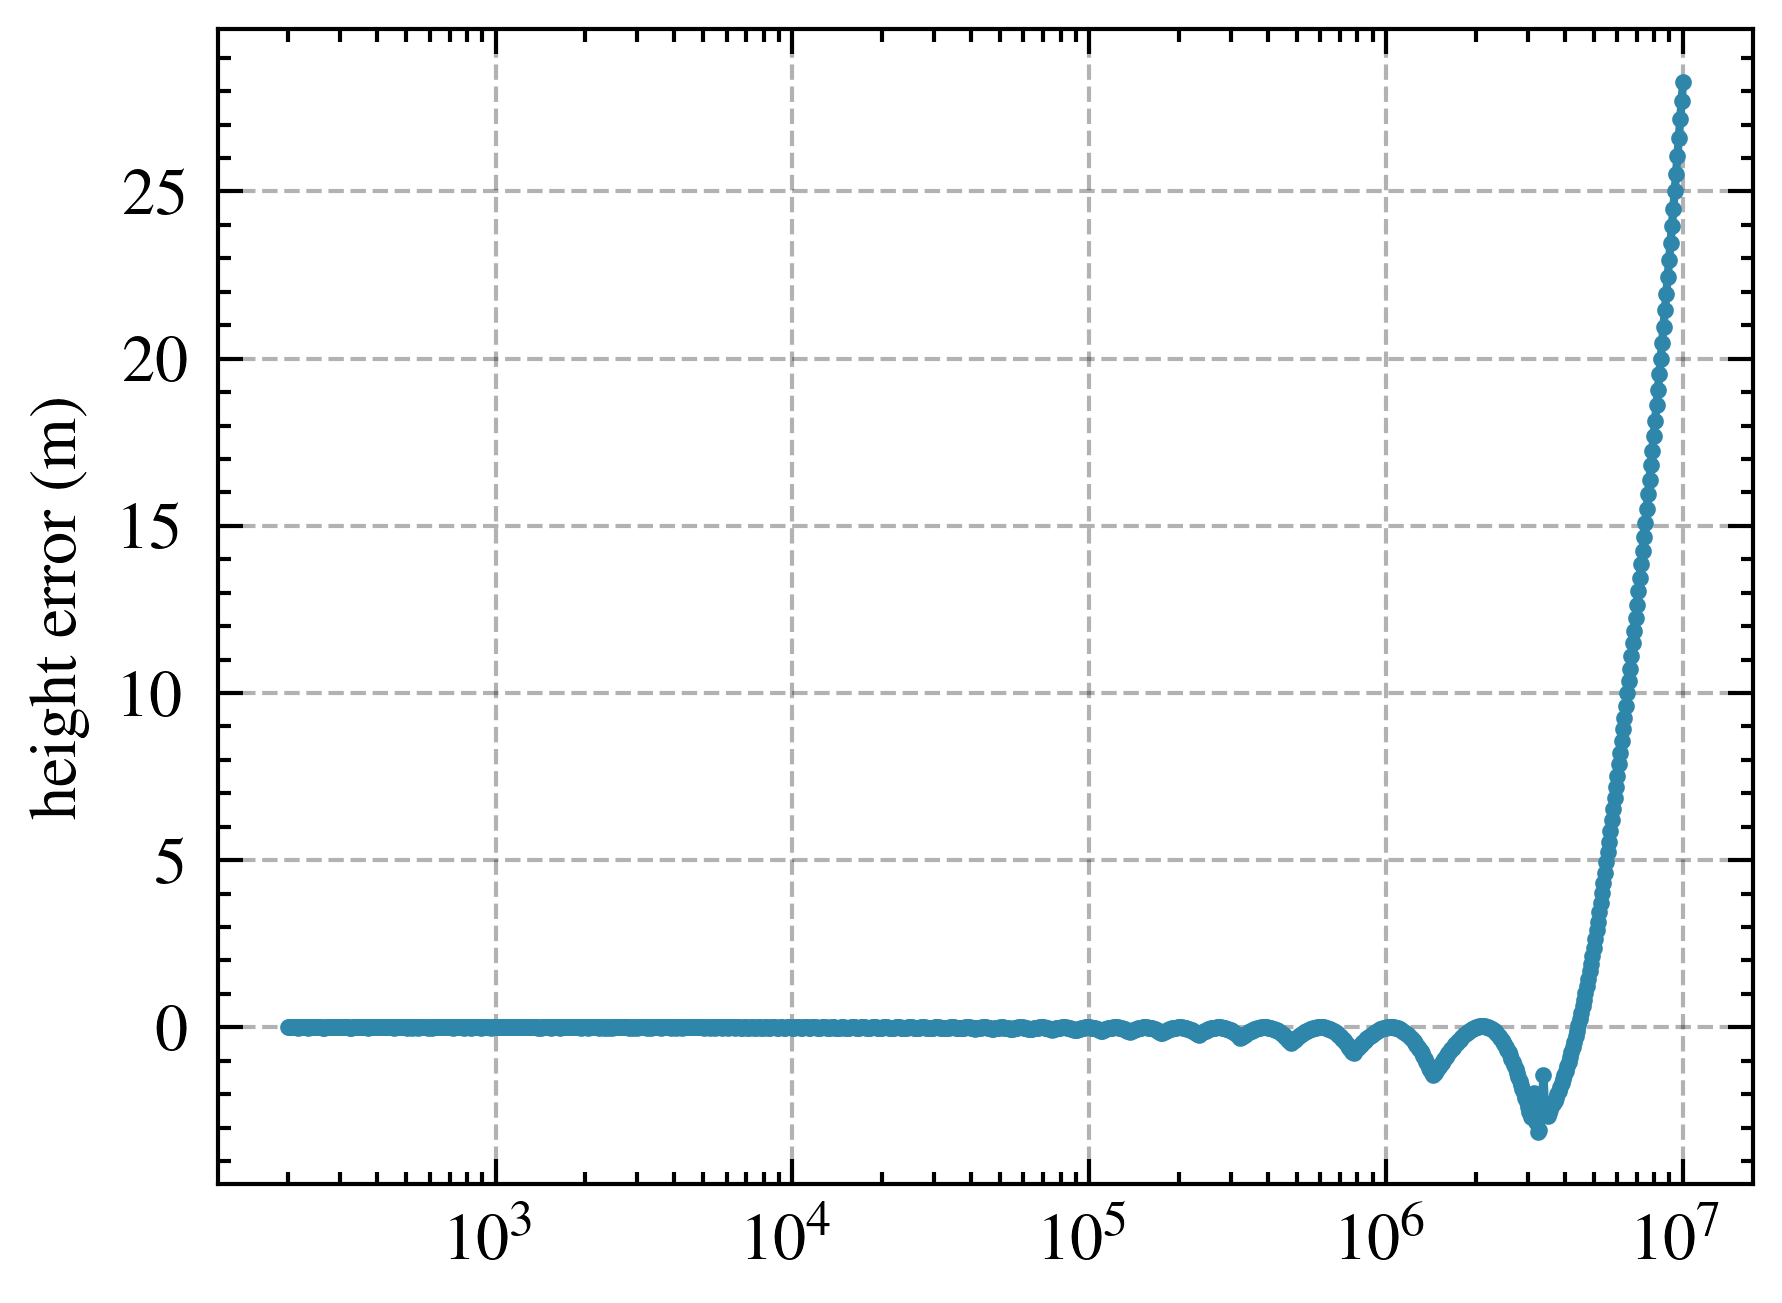

In [92]:
import matplotlib.pyplot as plt
import scienceplots
import numpy as np

# Read data from CSV using NumPy
data = np.genfromtxt('first_bouncing_data.csv', delimiter=',', skip_header=1)

# Extract x and y columns
x = data[:, 0]  # First column
y = data[:, 1]  # Second column

with plt.style.context(['science','ieee', 'grid']):
  legendStrs = []
  linestyles = ["-", ":", "--", "-."]
  scientific_colors = [
        '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
        '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
  ]
  plt.semilogx(x, y, marker='o', markersize=1, linewidth=1, color=scientific_colors[0])
  # plt.legend(loc="best", fontsize=8)
  # plt.legend(framealpha=0.9, loc="upper right")
  # plt.ylim(top=5.5, bottom=-0.5)
  plt.ylabel(r'height error (m)')
  plt.grid(True, linestyle='--', alpha=0.3)
  # plt.xlabel(r'Time (s)')
  # plt.title('Bouncing ball by proposed method')
  # plt.grid(True, alpha=0.3)
  # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data_sire.pdf", format="pdf")
  plt.show()

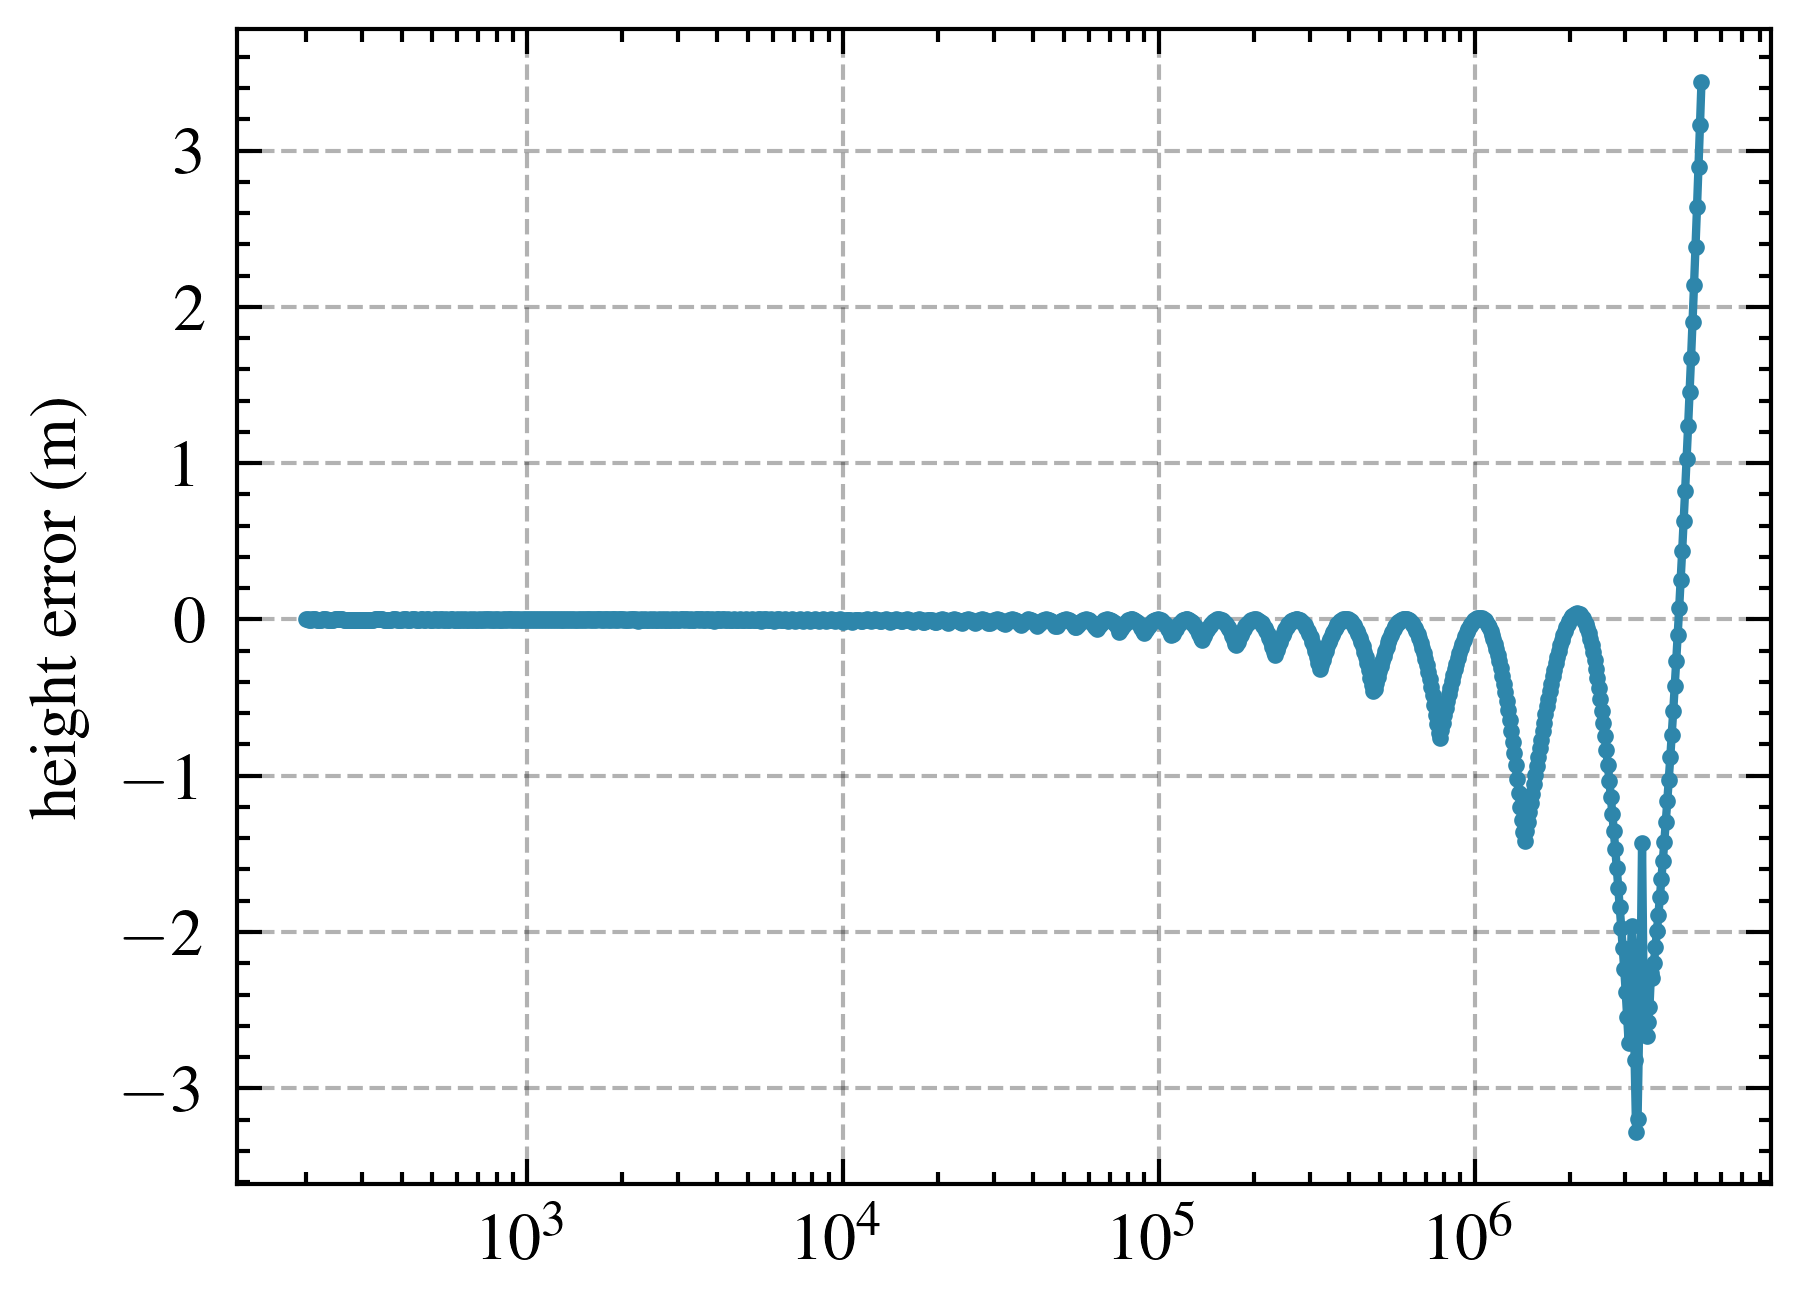

In [72]:
n = -60
with plt.style.context(['science','ieee', 'grid']):
  plt.semilogx(parameters[:n], heights[:n], marker='o', markersize=1, linewidth=1, color=scientific_colors[0])
  # plt.legend(loc="best", fontsize=8)
  # plt.legend(framealpha=0.9, loc="upper right")
  # plt.ylim(top=5.5, bottom=-0.5)
  plt.ylabel(r'height error (m)')
  plt.grid(True, linestyle='--', alpha=0.3)
  # plt.xlabel(r'Time (s)')
  # plt.title('Bouncing ball by proposed method')
  # plt.grid(True, alpha=0.3)
  # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data_sire.pdf", format="pdf")
  plt.show()

## Snapshots

In [ ]:
import mujoco
import numpy as np
from PIL import Image
import copy
from os.path import abspath
import os

def capture_frame(renderer, data, path):
    """更新渲染器并保存当前帧为图片"""
    # 同步模拟数据到渲染器
    renderer.update_scene(data)
    # 将渲染好的图像转换为像素数组
    pixels = renderer.render()
    # 使用PIL保存图像
    img = Image.fromarray(pixels)
    return img
    # img.save(path)
    # print(f"截图已保存至: {path}")

# 最简单的方法
parameters = [2e3, 2e5, 3e6, 2e8]
# parameters = [[2e2, 0], [2e30, 0]]
sim_duration = 2.2
all_results = []

heights = np.zeros(np.size(parameters))

# 运行三次不同参数的仿真
for param_idx, stiffness in enumerate(parameters):
    # print(f"运行仿真 {param_idx+1}, solref={solref}")
    
    # MuJoCo模型XML字符串，使用当前参数
    MUJOCO_MODEL_XML = f"""
<mujoco>
  <option timestep="0.001"/>
<visual>
  <global offwidth="1280" offheight="720" azimuth="-140" elevation="-20"/>
    <headlight diffuse="0.6 0.6 0.6" ambient="0.1 0.1 0.1" specular="0.9 0.9 0.9"/>
    <rgba haze="0.15 0.25 0.35 1"/>
  </visual>
  <default>
    <geom solref="-{stiffness} 0"/>
  </default>

  <asset>
    <texture type="skybox" builtin="gradient" rgb1="0.3 0.5 0.8" rgb2="0.8 0.8 0.8" width="512" height="3072"/>
    <texture type="2d" name="groundplane" builtin="checker" mark="edge" rgb1="0.2 0.3 0.4" rgb2="0.1 0.2 0.3" markrgb="0.8 0.8 0.8" width="300" height="300"/>
    <material name="groundplane" texture="groundplane" texuniform="true" texrepeat="5 5" reflectance="0.2"/>
  </asset>
  <worldbody>
      <light pos="1 0 3.5" dir="0 0 -1" directional="true"/>
    <!-- 地面 -->
    <geom name="ground" type="box" size="2.5 2.5 0.5" pos="0 0 -0.50" rgba="0.8 0.9 0.8 1"/>
    
    <!-- 小球 -->
    <body name="ball" pos="0 0 4.5">
      <freejoint/>
      <geom name="ball_geom" type="sphere" size="0.5" rgba="0.9 0.2 0.2 1" mass="1"/>
    </body>
    <camera name="my_camera" mode="fixed" fovy="75" pos="8 0 2" quat="0.55734541 0.43516215 0.43516215 0.55734541"/>
  </worldbody>
  <!-- 重力设置 -->
  <option gravity="0 0 -9.81"/>
</mujoco>
"""

    # 创建模型和仿真环境
    model = mujoco.MjModel.from_xml_string(MUJOCO_MODEL_XML)
    # 2. 创建离屏渲染器
    renderer = mujoco.Renderer(model, height=720, width=1280)
    data = mujoco.MjData(model)
    # 设置仿真时长
    simulation_time = 2.2 # 仿真时间（秒）
    num_steps = int(simulation_time / model.opt.timestep)

    # 存储时间和高度数据
    # time_points = np.zeros(num_steps)
    # velocity_points = np.zeros(num_steps)

    # 运行仿真
    firstBounceHeight = 0
    # updated_max_height = False
    for i in range(num_steps):
        # 执行仿真步骤
        mujoco.mj_step(model, data)
        
        # 记录时间、高度和速度
        # time_points[i] = data.time
        height = data.qpos[2] - 0.5  # z坐标
        # velocity_points[i] = data.qvel[2]  # z方向速度
        if i > 900:
          if height > firstBounceHeight:
            firstBounceHeight = height
            data1 = copy.deepcopy(data)
            # updated_max_height = True
          # if updated_max_height:
          #    if height < firstBounceHeight:
          #       data.qpos = qpos_backup.copy()
          #       img = capture_frame(renderer, data, "")
    cam_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_CAMERA, "my_camera")
    # data.qpos = qpos_backup.copy()
    # data.qpos[2] = 1
    # img = capture_frame(renderer, data, "")
    renderer.update_scene(data1, camera=cam_id) # 在截图函数中使用
    print(firstBounceHeight, data1.qpos)
    # 将渲染好的图像转换为像素数组
    pixels = renderer.render()
    # 使用PIL保存图像
    img = Image.fromarray(pixels)
    renderer.close()
    print(img._size)
    cropped_img = img.crop((450, 0, 820, 450))
    cropped_img.save(abspath(os.getcwd()) + f"/pic/{str(stiffness)}.png")

3.995765958884256 [0.         0.         4.49576596 1.         0.         0.
 0.        ]
(1280, 720)
4.001208909105773 [0.         0.         4.50120891 1.         0.         0.
 0.        ]
(1280, 720)
1.6419671712959585 [0.         0.         2.14196717 1.         0.         0.
 0.        ]
(1280, 720)
1020.5484803848893 [0.00000000e+00 0.00000000e+00 1.02104848e+03 1.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00]
(1280, 720)


In [6]:
import mujoco
import numpy as np
from PIL import Image
import copy
from os.path import abspath
import os

def capture_frame(renderer, data, path):
    """更新渲染器并保存当前帧为图片"""
    # 同步模拟数据到渲染器
    renderer.update_scene(data)
    # 将渲染好的图像转换为像素数组
    pixels = renderer.render()
    # 使用PIL保存图像
    img = Image.fromarray(pixels)
    return img
    # img.save(path)
    # print(f"截图已保存至: {path}")

# 最简单的方法
parameters = [2e3, 2e5, 3e6, 2e8]
# parameters = [[2e2, 0], [2e30, 0]]
sim_duration = 2.2
all_results = []

heights = np.zeros(np.size(parameters))

# 运行三次不同参数的仿真
for param_idx, stiffness in enumerate(parameters):
    # print(f"运行仿真 {param_idx+1}, solref={solref}")
    
    # MuJoCo模型XML字符串，使用当前参数
    MUJOCO_MODEL_XML = f"""
<mujoco>
  <option timestep="0.001"/>
<visual>
  <global offwidth="1280" offheight="720" azimuth="-140" elevation="-20"/>
    <headlight diffuse="0.6 0.6 0.6" ambient="0.1 0.1 0.1" specular="0.9 0.9 0.9"/>
    <rgba haze="0.15 0.25 0.35 1"/>
  </visual>
  <default>
    <geom solref="-{stiffness} 0"/>
  </default>

  <asset>
    <texture type="skybox" builtin="gradient" rgb1="0.3 0.5 0.8" rgb2="0.8 0.8 0.8" width="512" height="3072"/>
    <texture type="2d" name="groundplane" builtin="checker" mark="edge" rgb1="0.2 0.3 0.4" rgb2="0.1 0.2 0.3" markrgb="0.8 0.8 0.8" width="300" height="300"/>
    <material name="groundplane" texture="groundplane" texuniform="true" texrepeat="5 5" reflectance="0.2"/>
  </asset>
  <worldbody>
      <light pos="1 0 3.5" dir="0 0 -1" directional="true"/>
    <!-- 地面 -->
    <geom name="ground" type="box" size="2.5 2.5 0.5" pos="0 0 -0.50" rgba="0.8 0.9 0.8 1"/>
    
    <!-- 小球 -->
    <body name="ball" pos="0 0 4.5">
      <freejoint/>
      <geom name="ball_geom" type="sphere" size="0.5" rgba="0.9 0.2 0.2 1" mass="1"/>
    </body>
    <camera name="my_camera" mode="fixed" fovy="20" pos="30 0 0" quat="0.5 0.5 0.5 0.5"/>
    
  </worldbody>
  <!-- 重力设置 -->
  <option gravity="0 0 -9.81"/>
</mujoco>
"""
# <camera name="my_camera" mode="fixed" fovy="75" pos="8 0 2" quat="0.55734541 0.43516215 0.43516215 0.55734541"/>
    # 创建模型和仿真环境
    model = mujoco.MjModel.from_xml_string(MUJOCO_MODEL_XML)
    # 2. 创建离屏渲染器
    renderer = mujoco.Renderer(model, height=720, width=1280)
    data = mujoco.MjData(model)
    # 设置仿真时长
    simulation_time = 2.2 # 仿真时间（秒）
    num_steps = int(simulation_time / model.opt.timestep)

    # 存储时间和高度数据
    # time_points = np.zeros(num_steps)
    # velocity_points = np.zeros(num_steps)

    # 运行仿真
    firstBounceHeight = 0
    # updated_max_height = False
    for i in range(num_steps):
        # 执行仿真步骤
        mujoco.mj_step(model, data)
        
        # 记录时间、高度和速度
        # time_points[i] = data.time
        height = data.qpos[2] - 0.5  # z坐标
        # velocity_points[i] = data.qvel[2]  # z方向速度
        if i > 900:
          if height > firstBounceHeight:
            firstBounceHeight = height
            data1 = copy.deepcopy(data)
            # updated_max_height = True
          # if updated_max_height:
          #    if height < firstBounceHeight:
          #       data.qpos = qpos_backup.copy()
          #       img = capture_frame(renderer, data, "")
    cam_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_CAMERA, "my_camera")
    # data.qpos = qpos_backup.copy()
    # data.qpos[2] = 1
    # img = capture_frame(renderer, data, "")
    renderer.update_scene(data1, camera=cam_id) # 在截图函数中使用
    print(firstBounceHeight, data1.qpos)
    # 将渲染好的图像转换为像素数组
    pixels = renderer.render()
    # 使用PIL保存图像
    img = Image.fromarray(pixels)
    renderer.close()
    print(img._size)
    cropped_img = img.crop((445, 0, 835, 465))
    cropped_img.save(abspath(os.getcwd()) + f"/pic/{str(stiffness)}.png")

3.995765958884256 [0.         0.         4.49576596 1.         0.         0.
 0.        ]
(1280, 720)
4.001208909105773 [0.         0.         4.50120891 1.         0.         0.
 0.        ]
(1280, 720)
1.6419671712959585 [0.         0.         2.14196717 1.         0.         0.
 0.        ]
(1280, 720)
1020.5484803848893 [0.00000000e+00 0.00000000e+00 1.02104848e+03 1.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00]
(1280, 720)


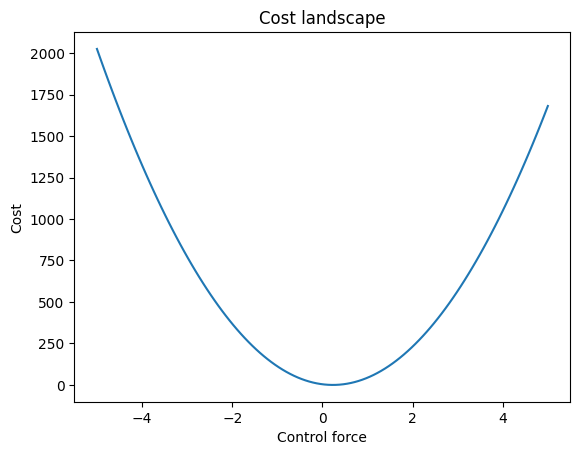

0 -3.45612738744191 5.29022196362973
1 51.10809488921407 1006.3505730762962
2 -701.4597734471226 191436.48089441928
3 9678.206155631933 36416659.616816245
4 -133481.5962811967 6927483746.31889
5 1841027.278230522 1317804377634.9717
6 -25392311.78426948 250684213923686.22
7 350251288.21573055 4.768822317597134e+16
8 -4860423911.784269 9.073317980793658e+18
9 -4417543911.784269 1.077640283046231e+19
10 -4294971111.784269 2.7153283959720545e+18
11 -4218363111.7842693 1.6191282140534428e+18
12 -4165134311.7842693 1.1238202330431551e+18
13 -4124468711.7842693 8.467931539329592e+17
14 -4091579111.7842693 6.766115923961242e+17
15 -4064404711.7842693 5.567315987414923e+17
16 -4042030311.7842693 4.5548689240674214e+17
17 -4022158311.7842693 4.008267489537452e+17
18 -4004670311.7842693 3.519051847043781e+17
19 -3989271911.7842693 3.0815571225916896e+17
20 -3975801511.7842693 2.6904760548816566e+17
21 -3963500711.7842693 2.4480162660806813e+17
22 -3952278311.7842693 2.2242955848358518e+17
23 -394

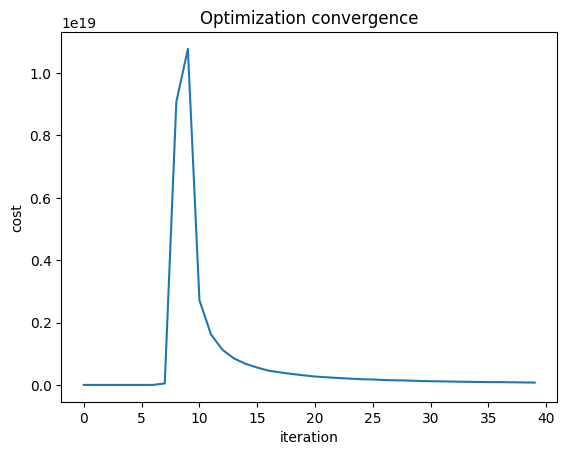

In [7]:
import mujoco
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# MuJoCo model
# -------------------------

XML = """
<mujoco>

    <option timestep="0.002" gravity="0 0 -9.81"/>

    <default>
        <geom friction="1 0.005 0.0001"/>
    </default>

    <worldbody>

        <geom name="floor"
              type="plane"
              size="5 5 0.1"
              pos="0 0 0"
              solref="-10000 -200"/>

        <body name="ball" pos="0 0 0.05">

            <joint name="ballx" type="slide" axis="1 0 0"/>
            <joint name="bally" type="slide" axis="0 1 0"/>

            <geom type="sphere"
                  size="0.05"
                  density="1000"
                  solref="-10000 -200"/>

        </body>

    </worldbody>

</mujoco>
"""

# -------------------------

dt = 0.002
sim_time = 3.0
steps = int(sim_time/dt)

target_x = 2.0


# -------------------------
# simulation
# -------------------------

def run_sim(force):

    model = mujoco.MjModel.from_xml_string(XML)
    data = mujoco.MjData(model)

    for i in range(steps):

        data.qfrc_applied[0] = force

        mujoco.mj_step(model, data)

    return data.qpos[0]


# -------------------------
# cost
# -------------------------

def cost(u):

    x_final = run_sim(u)

    return (x_final - target_x)**2


# -------------------------
# gradient
# -------------------------

def gradient(u, eps=1e-3):

    return (cost(u+eps) - cost(u-eps))/(2*eps)


# -------------------------
# scan cost landscape
# -------------------------

u_scan = np.linspace(-5,5,120)
cost_vals = [cost(u) for u in u_scan]

plt.figure()
plt.plot(u_scan, cost_vals)
plt.xlabel("Control force")
plt.ylabel("Cost")
plt.title("Cost landscape")
plt.show()


# -------------------------
# gradient descent
# -------------------------

u = 0.5
alpha = 0.1

history_cost = []

for i in range(40):

    g = gradient(u)
    c = cost(u)

    u = u - alpha*g

    history_cost.append(c)

    print(i, u, c)

plt.figure()
plt.plot(history_cost)
plt.xlabel("iteration")
plt.ylabel("cost")
plt.title("Optimization convergence")
plt.show()

Model dimensions: nq=8, nv=7, total state dim=15

--- Running Soft contact ---


C:\Users\leiti\AppData\Local\Temp\ipykernel_41696\2908000617.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  data.ctrl[0] = u
C:\Users\leiti\AppData\Local\Temp\ipykernel_41696\2908000617.py:74: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(0.5 * err.T @ self.Q @ err + 0.5 * u * self.R * u)


Iter 0, loss = 22.5000, |k| = 0.0000e+00, alpha = 1.0000
Converged at iteration 0

--- Running Hard contact ---
Iter 0, loss = 22.5000, |k| = 0.0000e+00, alpha = 1.0000
Converged at iteration 0


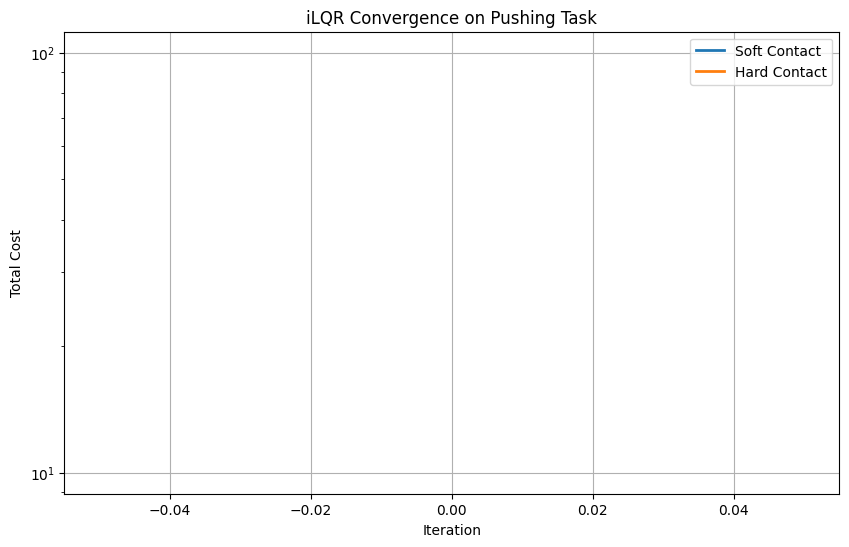

In [12]:
import mujoco
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# 1. 模型创建函数
# ------------------------------
def create_model(soft=True):
    solref = "0.02 1" if soft else "0.001 1"
    xml = f"""
    <mujoco>
        <option timestep="0.01" iterations="100"/>
        <worldbody>
            <geom name="ground" type="plane" pos="0 0 0" size="5 5 0.1"/>
            <body name="slider" pos="0.5 0 0.1">
                <freejoint/>
                <geom name="slider_geom" type="box" size="0.1 0.1 0.1" mass="1.0"
                      solimp=".9 .99 .003" solref="{solref}"/>
            </body>
            <body name="pusher" pos="0 0 0.1">
                <joint type="slide" axis="1 0 0" name="pusher_x"/>
                <geom name="pusher_geom" type="sphere" size="0.05" mass="0.1"
                      solimp=".9 .99 .003" solref="{solref}"/>
            </body>
        </worldbody>
        <actuator>
            <motor joint="pusher_x" name="motor_x" ctrlrange="-10 10"/>
        </actuator>
    </mujoco>
    """
    return mujoco.MjModel.from_xml_string(xml)

# ------------------------------
# 2. 动力学函数（每次新建 data）
# ------------------------------
def dynamics_step(model, x, u):
    nq = model.nq
    nv = model.nv
    data = mujoco.MjData(model)
    data.qpos[:] = x[:nq]
    data.qvel[:] = x[nq:]
    data.ctrl[0] = u
    mujoco.mj_step(model, data)
    return np.concatenate([data.qpos[:nq].copy(), data.qvel[:nv].copy()])

def compute_dynamics_derivatives(model, x, u, eps=1e-6):
    n = len(x)
    m = 1
    x_next = dynamics_step(model, x, u)
    f_x = np.zeros((n, n))
    for i in range(n):
        x_pert = x.copy()
        x_pert[i] += eps
        x_next_pert = dynamics_step(model, x_pert, u)
        f_x[:, i] = (x_next_pert - x_next) / eps
    f_u = np.zeros((n, m))
    u_pert = u + eps
    x_next_pert = dynamics_step(model, x, u_pert)
    f_u[:, 0] = (x_next_pert - x_next) / eps
    return f_x, f_u

# ------------------------------
# 3. 代价函数（返回标量）
# ------------------------------
class QuadraticCost:
    def __init__(self, Q, R, Qf, x_target):
        self.Q = Q
        self.R = R
        self.Qf = Qf
        self.x_target = x_target

    def l(self, x, u):
        err = x - self.x_target
        return float(0.5 * err.T @ self.Q @ err + 0.5 * u * self.R * u)

    def l_x(self, x, u):
        return self.Q @ (x - self.x_target)

    def l_u(self, x, u):
        return self.R * u

    def l_xx(self, x, u):
        return self.Q

    def l_uu(self, x, u):
        return np.array([[self.R]])

    def l_xu(self, x, u):
        return np.zeros((len(x), 1))

    def l_final(self, x):
        err = x - self.x_target
        return float(0.5 * err.T @ self.Qf @ err)

    def l_final_x(self, x):
        return self.Qf @ (x - self.x_target)

    def l_final_xx(self, x):
        return self.Qf

# ------------------------------
# 4. iLQR 算法
# ------------------------------
def ilqr(model, cost, x0, U_init, T, max_iters=50, tol=1e-4):
    U = [u.copy() for u in U_init]
    n = len(x0)
    loss_history = []

    for it in range(max_iters):
        # ----- 前向仿真得到标称轨迹 -----
        X = [x0]
        total_cost = cost.l_final(x0)
        for t in range(T):
            x_next = dynamics_step(model, X[t], U[t])
            X.append(x_next)
            total_cost += cost.l(X[t], U[t])
        total_cost += cost.l_final(X[T])
        loss_history.append(float(total_cost))

        # ----- 反向传播 -----
        S = cost.l_final_xx(X[T])
        s = cost.l_final_x(X[T])
        k = [None] * T
        K = [None] * T

        for t in reversed(range(T)):
            f_x, f_u = compute_dynamics_derivatives(model, X[t], U[t])
            c_x = cost.l_x(X[t], U[t])
            c_u = cost.l_u(X[t], U[t])
            c_xx = cost.l_xx(X[t], U[t])
            c_uu = cost.l_uu(X[t], U[t])
            c_xu = cost.l_xu(X[t], U[t])

            Q_x = c_x + f_x.T @ s
            Q_u = c_u + f_u.T @ s
            Q_xx = c_xx + f_x.T @ S @ f_x
            Q_uu = c_uu + f_u.T @ S @ f_u
            Q_xu = c_xu + f_x.T @ S @ f_u

            Q_uu_inv = np.linalg.inv(Q_uu)
            K[t] = Q_uu_inv @ Q_xu.T
            k[t] = -Q_uu_inv @ Q_u

            S = Q_xx - K[t].T @ Q_uu @ K[t]
            s = Q_x - K[t].T @ Q_uu @ k[t]

        # ----- 线搜索 -----
        alphas = [1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125]
        best_U = None
        best_X = None
        best_cost = np.inf
        best_alpha = 0

        for alpha in alphas:
            U_new = []
            X_new = [x0]
            total_cost_new = cost.l_final(x0)  # 初始代价
            for t in range(T):
                du = alpha * k[t] + K[t] @ (X_new[t] - X[t])
                u_new = U[t] + du.flatten()
                u_new = np.clip(u_new, -10, 10)
                U_new.append(u_new)
                x_next = dynamics_step(model, X_new[t], u_new)
                X_new.append(x_next)
                total_cost_new += cost.l(X_new[t], u_new)
            total_cost_new += cost.l_final(X_new[T])
            total_cost_new = float(total_cost_new)  # 确保标量

            if total_cost_new < best_cost:
                best_cost = total_cost_new
                best_U = U_new
                best_X = X_new
                best_alpha = alpha

        U = best_U
        X = best_X

        # 检查收敛
        k_norm = np.linalg.norm(np.concatenate([ki.flatten() for ki in k]))
        print(f"Iter {it}, loss = {float(total_cost):.4f}, |k| = {k_norm:.4e}, alpha = {best_alpha:.4f}")
        if k_norm < tol:
            print(f"Converged at iteration {it}")
            break

    return U, X, loss_history

# ------------------------------
# 5. 主程序
# ------------------------------
def main():
    model = create_model(soft=True)  # 仅获取维度
    nq = model.nq   # 8
    nv = model.nv   # 7
    n = nq + nv     # 15
    print(f"Model dimensions: nq={nq}, nv={nv}, total state dim={n}")

    T = 30
    dt = 0.01

    # 目标状态：滑块 x = 0.8
    x_target = np.zeros(n)
    slider_x_idx = 1  # qpos 中滑块 x 的索引（pusher_x 在 0，slider_x 在 1）
    x_target[slider_x_idx] = 0.8

    # 代价权重
    Q = np.zeros((n, n))
    Q[slider_x_idx, slider_x_idx] = 10.0
    Qf = np.zeros((n, n))
    Qf[slider_x_idx, slider_x_idx] = 100.0
    R = 0.01
    cost = QuadraticCost(Q, R, Qf, x_target)

    # 初始状态
    x0 = np.zeros(n)
    x0[0] = 0.0               # pusher x
    x0[1] = 0.5               # slider x
    x0[5] = 1.0               # 四元数 w (单位四元数)
    # 速度全零

    # 初始控制序列（全零）
    U_init = [np.array([0.0]) for _ in range(T)]

    # 分别运行软、硬接触
    results = {}
    for soft in [True, False]:
        print(f"\n--- Running {'Soft' if soft else 'Hard'} contact ---")
        model = create_model(soft)
        U_opt, X_opt, loss_hist = ilqr(model, cost, x0, U_init, T, max_iters=50)
        results['soft' if soft else 'hard'] = loss_hist

    # 绘制收敛曲线
    plt.figure(figsize=(10, 6))
    plt.plot(results['soft'], label='Soft Contact', linewidth=2)
    plt.plot(results['hard'], label='Hard Contact', linewidth=2)
    plt.xlabel('Iteration')
    plt.ylabel('Total Cost')
    plt.title('iLQR Convergence on Pushing Task')
    plt.legend()
    plt.grid(True)
    plt.yscale('log')
    plt.show()

if __name__ == "__main__":
    main()

In [17]:
import mujoco
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ------------------------------
# 1. 模型创建函数（软/硬接触）
# ------------------------------
def create_model(soft=True):
    solref = "0.02 1" if soft else "0.001 1"
    xml = f"""
    <mujoco>
        <option timestep="0.01" iterations="100"/>
        <worldbody>
            <geom name="ground" type="plane" pos="0 0 0" size="5 5 0.1"/>
            <body name="slider" pos="0.5 0 0.1">
                <freejoint/>
                <geom name="slider_geom" type="box" size="0.1 0.1 0.1" mass="1.0"
                      solimp=".9 .99 .003" solref="{solref}"/>
            </body>
            <body name="pusher" pos="0 0 0.1">
                <joint type="slide" axis="1 0 0" name="pusher_x"/>
                <geom name="pusher_geom" type="sphere" size="0.05" mass="0.1"
                      solimp=".9 .99 .003" solref="{solref}"/>
            </body>
        </worldbody>
        <actuator>
            <motor joint="pusher_x" name="motor_x" ctrlrange="-10 10"/>
        </actuator>
    </mujoco>
    """
    return mujoco.MjModel.from_xml_string(xml)

# ------------------------------
# 2. 仿真函数：给定控制序列，返回最终滑块 x 坐标
# ------------------------------
def simulate(model, ctrl_sequence, render=False):
    """
    ctrl_sequence: 每个时间步的控制力（标量），长度 T
    返回最终滑块 x 坐标
    """
    data = mujoco.MjData(model)
    T = len(ctrl_sequence)
    for t in range(T):
        data.ctrl[0] = ctrl_sequence[t]
        mujoco.mj_step(model, data)
        if render:
            # 可选：渲染（需要 viewer）
            pass
    # 滑块 x 坐标在 qpos[1]
    return data.qpos[1]

# ------------------------------
# 3. 代价函数（用于优化）
# ------------------------------
def cost_function(ctrl_sequence, model, target_x):
    """
    目标：使最终滑块 x 接近 target_x，同时惩罚大控制力
    """
    final_x = simulate(model, ctrl_sequence)
    # 代价 = 位置误差平方 + 控制能量惩罚
    cost = (final_x - target_x)**2 + 0.01 * np.sum(np.square(ctrl_sequence))
    return cost

# ------------------------------
# 4. 梯度函数（有限差分）
# ------------------------------
def gradient(ctrl_sequence, model, target_x, eps=1e-4):
    grad = np.zeros_like(ctrl_sequence)
    f0 = cost_function(ctrl_sequence, model, target_x)
    for i in range(len(ctrl_sequence)):
        ctrl_pert = ctrl_sequence.copy()
        ctrl_pert[i] += eps
        f1 = cost_function(ctrl_pert, model, target_x)
        grad[i] = (f1 - f0) / eps
    return grad

# ------------------------------
# 5. 主程序：对比软/硬接触下的优化
# ------------------------------
def main():
    # 参数
    T = 20  # 时间步数
    target_x = 0.8  # 目标位置
    initial_ctrl = np.zeros(T)  # 初始控制全零（但为了产生接触，可以给一点初始推力）
    # 给一个初始斜坡，让推动器开始运动
    initial_ctrl[:5] = 1.0

    # 分别优化软、硬接触模型
    results = {}
    for soft in [True, False]:
        model = create_model(soft)
        print(f"\n--- Optimizing {'Soft' if soft else 'Hard'} contact model ---")
        
        # 使用 L-BFGS 优化
        def obj_func(x):
            return cost_function(x, model, target_x)
        
        def grad_func(x):
            return gradient(x, model, target_x)
        
        res = minimize(
            obj_func,
            initial_ctrl,
            method='L-BFGS-B',
            jac=grad_func,
            bounds=[(-10, 10)] * T,
            options={'maxiter': 50, 'disp': True}
        )
        
        results['soft' if soft else 'hard'] = {
            'x': res.x,
            'fun': res.fun,
            'nit': res.nit,
            'history': []  # 需要手动记录迭代历史，这里简单记录最终值
        }
        # 为了绘制收敛曲线，我们可以手动记录每次迭代的代价（需要修改 minimize 回调）
        # 这里简化：只打印最终结果
        print(f"Final cost: {res.fun:.6f}")

    # 由于 minimize 不直接返回迭代历史，我们可以在每次迭代时通过回调记录
    # 为了简化，此处不画收敛曲线，直接输出结果对比
    print("\n=== Summary ===")
    for key in results:
        print(f"{key.capitalize()} contact final cost: {results[key]['fun']:.6f}")

    # 如果需要收敛曲线，可以手动实现梯度下降并记录
    # 下面提供一个简单的梯度下降示例（可选）
    # 省略...

if __name__ == "__main__":
    main()


--- Optimizing Soft contact model ---
Final cost: 0.640000

--- Optimizing Hard contact model ---
Final cost: 0.640000

=== Summary ===
Soft contact final cost: 0.640000
Hard contact final cost: 0.640000


C:\Users\leiti\AppData\Local\Temp\ipykernel_41696\1332884027.py:102: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


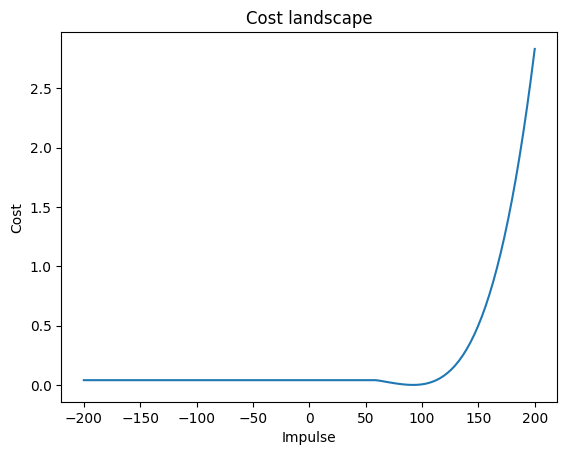

0 50.0 0.040003924096236085
1 50.0 0.040003924096236085
2 50.0 0.040003924096236085
3 50.0 0.040003924096236085
4 50.0 0.040003924096236085
5 50.0 0.040003924096236085
6 50.0 0.040003924096236085
7 50.0 0.040003924096236085
8 50.0 0.040003924096236085
9 50.0 0.040003924096236085
10 50.0 0.040003924096236085
11 50.0 0.040003924096236085
12 50.0 0.040003924096236085
13 50.0 0.040003924096236085
14 50.0 0.040003924096236085
15 50.0 0.040003924096236085
16 50.0 0.040003924096236085
17 50.0 0.040003924096236085
18 50.0 0.040003924096236085
19 50.0 0.040003924096236085
20 50.0 0.040003924096236085
21 50.0 0.040003924096236085
22 50.0 0.040003924096236085
23 50.0 0.040003924096236085
24 50.0 0.040003924096236085
25 50.0 0.040003924096236085
26 50.0 0.040003924096236085
27 50.0 0.040003924096236085
28 50.0 0.040003924096236085
29 50.0 0.040003924096236085


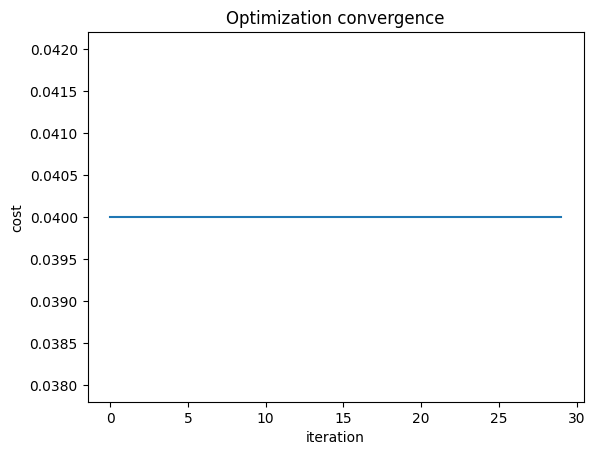

In [21]:
import mujoco
import numpy as np
import matplotlib.pyplot as plt

XML = """
<mujoco>

<option timestep="0.001" gravity="0 0 -9.81"/>

<worldbody>

    <geom type="plane" size="5 5 0.1" pos="0 0 0"/>

    <body pos="0 0 1">
        <joint type="free"/>
        <geom type="sphere" size="0.05" density="1000"/>
    </body>

</worldbody>

</mujoco>
"""

dt = 0.001
sim_time = 1.5
steps = int(sim_time/dt)

target_height = 1.2

# --------------------

def run_sim(u):

    model = mujoco.MjModel.from_xml_string(XML)
    data = mujoco.MjData(model)

    max_height = 0

    for i in range(steps):

        # short impulse
        if 100 < i < 120:
            data.qfrc_applied[2] = u
        else:
            data.qfrc_applied[2] = 0

        mujoco.mj_step(model,data)

        max_height = max(max_height,data.qpos[2])

    return max_height


# --------------------

def cost(u):

    h = run_sim(u)

    return (h-target_height)**2


def gradient(u,eps=1e-2):

    return (cost(u+eps)-cost(u-eps))/(2*eps)

# --------------------
# cost landscape
# --------------------

u_scan = np.linspace(-200,200,120)
cost_vals = [cost(u) for u in u_scan]

plt.figure()
plt.plot(u_scan,cost_vals)
plt.xlabel("Impulse")
plt.ylabel("Cost")
plt.title("Cost landscape")
plt.show()

# --------------------
# gradient descent
# --------------------

u = 50
alpha = 0.01

history = []

for i in range(30):

    g = gradient(u)
    c = cost(u)

    u -= alpha*g
    history.append(c)

    print(i,u,c)

plt.figure()
plt.plot(history)
plt.xlabel("iteration")
plt.ylabel("cost")
plt.title("Optimization convergence")
plt.show()


========== Optimizing SOFT contact model ==========
Initial control (constant 50) -> slider final x = 6.4562, pusher final x = 6.2563


C:\Users\leiti\AppData\Local\Temp\ipykernel_41696\1038112333.py:82: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


Optimized cost: 0.077048, slider final x = 0.7754

========== Optimizing HARD contact model ==========
Initial control (constant 50) -> slider final x = 6.4562, pusher final x = 6.2563
Optimized cost: 0.077048, slider final x = 0.7754


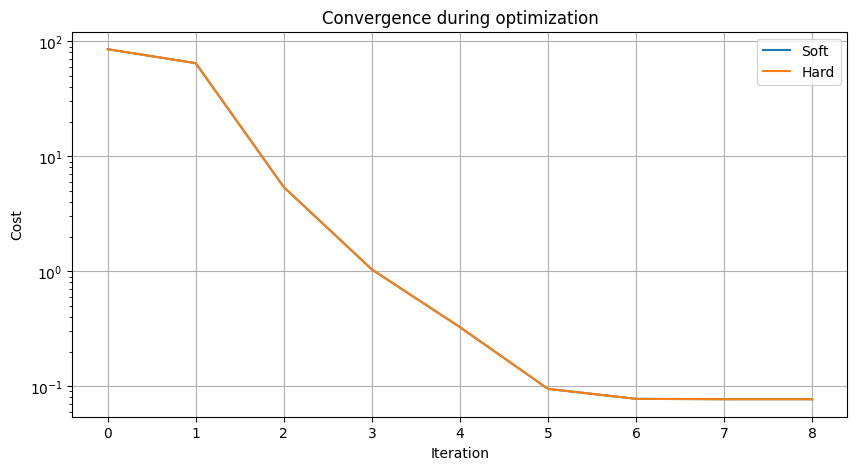

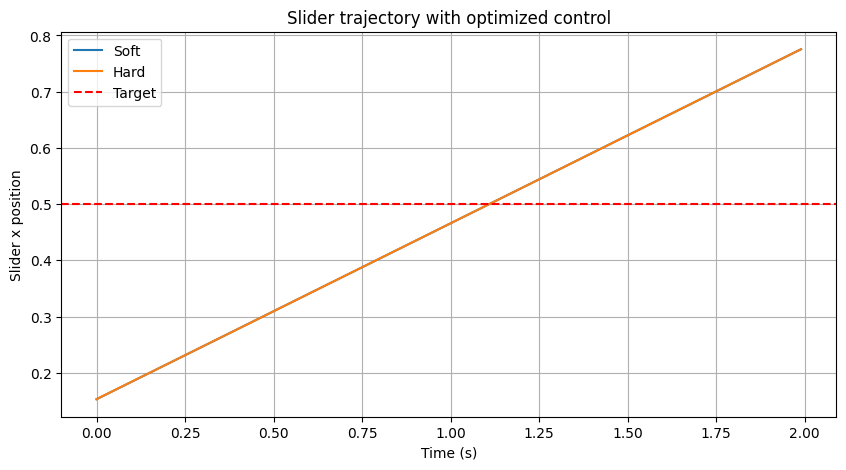

In [38]:
import mujoco
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ------------------------------
# 1. 模型创建函数（软/硬接触）
# ------------------------------
def create_model(soft=True):
    solref = "0.02 1" if soft else "0.0005 1"
    xml = f"""
    <mujoco>
        <option timestep="0.01" gravity="0 0 0"/>
        <worldbody>
            <!-- 滑块（freejoint）在前，占据 qpos[0:7] -->
            <body name="slider" pos="0.15 0 0">
                <freejoint/>
                <geom type="box" size="0.1 0.1 0.1" density="1000" 
                      solref="{solref}" solimp=".9 .99 .003"/>
            </body>
            <!-- 推动器（slide joint）在后，占据 qpos[7] -->
            <body name="pusher" pos="0 0 0">
                <joint type="slide" axis="1 0 0" name="pusher_x"/>
                <geom type="box" size="0.1 0.1 0.1" density="1000"
                      solref="{solref}" solimp=".9 .99 .003"/>
            </body>
        </worldbody>
        <actuator>
            <motor joint="pusher_x" ctrlrange="-100 100"/>
        </actuator>
    </mujoco>
    """
    return mujoco.MjModel.from_xml_string(xml)

# ------------------------------
# 2. 仿真函数（正确索引滑块 x 为 qpos[0]）
# ------------------------------
def simulate(model, ctrl_sequence, return_trajectory=False):
    data = mujoco.MjData(model)
    T = len(ctrl_sequence)
    slider_traj = []
    pusher_traj = []
    for t in range(T):
        data.ctrl[0] = ctrl_sequence[t]
        mujoco.mj_step(model, data)
        if return_trajectory:
            slider_traj.append(data.qpos[0])      # 滑块 x
            pusher_traj.append(data.qpos[7])      # 推动器 x
    final_slider_x = data.qpos[0]
    if return_trajectory:
        return final_slider_x, slider_traj, pusher_traj
    return final_slider_x

# ------------------------------
# 3. 代价函数
# ------------------------------
def cost_function(ctrl, model, target_x):
    final_x = simulate(model, ctrl)
    error = final_x - target_x
    return error**2 + 1e-4 * np.sum(np.square(ctrl))

# ------------------------------
# 4. 梯度（有限差分）
# ------------------------------
def gradient(ctrl, model, target_x, eps=1e-3):
    grad = np.zeros_like(ctrl)
    f0 = cost_function(ctrl, model, target_x)
    for i in range(len(ctrl)):
        ctrl_pert = ctrl.copy()
        ctrl_pert[i] += eps
        f1 = cost_function(ctrl_pert, model, target_x)
        grad[i] = (f1 - f0) / eps
    return grad

# ------------------------------
# 5. 优化器包装（记录历史）
# ------------------------------
def optimize_with_history(model, target_x, initial_ctrl, maxiter=50):
    history = []
    def callback(xk):
        history.append(cost_function(xk, model, target_x))
    res = minimize(
        cost_function,
        initial_ctrl,
        args=(model, target_x),
        method='L-BFGS-B',
        jac=gradient,
        bounds=[(-100, 100)] * len(initial_ctrl),
        options={'maxiter': maxiter, 'disp': False},
        callback=callback
    )
    return res, history

# ------------------------------
# 6. 主程序
# ------------------------------
def main():
    T = 200                     # 2 秒
    target_x = 0.5              # 目标位置
    initial_ctrl = np.ones(T) * 50.0   # 足够大的力

    results = {}
    histories = {}
    final_trajectories = {}

    for soft in [True, False]:
        print(f"\n========== Optimizing {'SOFT' if soft else 'HARD'} contact model ==========")
        model = create_model(soft)

        # 测试开环：观察初始控制下的运动
        final_slider, slider_traj, pusher_traj = simulate(model, initial_ctrl, return_trajectory=True)
        print(f"Initial control (constant 50) -> slider final x = {final_slider:.4f}, pusher final x = {pusher_traj[-1]:.4f}")
        if final_slider < 0.16:
            print("  WARNING: Slider barely moved; check contact.")

        # 运行优化
        res, hist = optimize_with_history(model, target_x, initial_ctrl, maxiter=500)
        results[soft] = res
        histories[soft] = hist

        # 获取优化后轨迹
        final_slider_opt, slider_traj_opt, _ = simulate(model, res.x, return_trajectory=True)
        final_trajectories[soft] = slider_traj_opt
        print(f"Optimized cost: {res.fun:.6f}, slider final x = {final_slider_opt:.4f}")

    # 绘制收敛曲线
    plt.figure(figsize=(10,5))
    for soft, hist in histories.items():
        label = 'Soft' if soft else 'Hard'
        plt.plot(hist, label=label)
    plt.xlabel('Iteration')
    plt.ylabel('Cost')
    plt.title('Convergence during optimization')
    plt.legend()
    plt.grid(True)
    plt.yscale('log')
    plt.show()

    # 绘制滑块轨迹
    plt.figure(figsize=(10,5))
    time = np.arange(T) * 0.01
    for soft, traj in final_trajectories.items():
        label = 'Soft' if soft else 'Hard'
        plt.plot(time, traj, label=label)
    plt.axhline(y=target_x, color='r', linestyle='--', label='Target')
    plt.xlabel('Time (s)')
    plt.ylabel('Slider x position')
    plt.title('Slider trajectory with optimized control')
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()

In [41]:
import numpy as np

# ------------------------------
# 参数设置
# ------------------------------
wall_pos = 10.0          # 墙壁位置
target_pos = 9.5         # 目标停止位置 (墙壁前方)
mass = 1.0
dt = 0.001
sim_steps = 2000

# 软接触参数
kp = 2000.0
kd = 20.0

# ------------------------------
# 核心仿真函数
# ------------------------------
def simulate(v0, contact_type='soft'):
    pos = 0.0
    vel = v0
    for _ in range(sim_steps):
        penetration = pos - wall_pos
        force = 0.0

        if contact_type == 'soft':
            if penetration > 0:
                # 接触力：负方向，大小 = kp*penetration + kd*vel
                force = -kp * penetration - kd * vel
        else:  # hard
            # 一旦穿透且速度向右，就视为完全非弹性碰撞，速度置零，位置钳位
            if penetration > 0 and vel > 0:
                vel = 0.0
                pos = wall_pos
            # 硬接触无持续力

        acc = force / mass
        vel += acc * dt
        pos += vel * dt

        # 稳定提前退出
        if abs(vel) < 1e-6 and abs(pos - wall_pos) < 1e-3:
            break
    return pos

def loss(pos):
    return 0.5 * (pos - target_pos) ** 2

def compute_gradient(v0, contact_type, eps=1e-5):
    pos0 = simulate(v0, contact_type)
    pos_plus = simulate(v0 + eps, contact_type)
    pos_minus = simulate(v0 - eps, contact_type)
    dpos_dv0 = (pos_plus - pos_minus) / (2 * eps)
    dL_dpos = pos0 - target_pos
    return dL_dpos * dpos_dv0, pos0

# ------------------------------
# 打印不同初速下的最终位置和梯度
# ------------------------------
print("=== 扫描初始速度 ===")
v0_list = np.arange(4.0, 8.5, 0.5)
print(f"{'v0':>6} | {'soft_pos':>10} | {'soft_grad':>12} | {'hard_pos':>10} | {'hard_grad':>12}")
for v in v0_list:
    sg, sp = compute_gradient(v, 'soft')
    hg, hp = compute_gradient(v, 'hard')
    print(f"{v:6.2f} | {sp:10.4f} | {sg:12.4e} | {hp:10.4f} | {hg:12.4e}")

# ------------------------------
# 使用梯度下降优化初速，使最终位置接近 target_pos
# ------------------------------
print("\n=== 梯度下降优化 (软接触) ===")
v_opt = 5.0          # 初始猜测
lr = 1e-4            # 学习率
for i in range(50):
    grad, pos = compute_gradient(v_opt, 'soft')
    v_opt -= lr * grad
    if i % 10 == 0:
        print(f"iter {i:2d}: v = {v_opt:.6f}, pos = {pos:.4f}, grad = {grad:.4e}")

print(f"\n优化后的初始速度: {v_opt:.6f}")
print(f"最终位置: {simulate(v_opt, 'soft'):.4f} (目标 {target_pos})")

=== 扫描初始速度 ===
    v0 |   soft_pos |    soft_grad |   hard_pos |    hard_grad
  4.00 |     8.0000 |  -3.0000e+00 |     8.0000 |  -3.0000e+00
  4.50 |     9.0000 |  -1.0000e+00 |     9.0000 |  -1.0000e+00
  5.00 |    10.0000 |   1.0000e+00 |    10.0000 |   1.0000e+00
  5.50 |     9.7023 |  -2.1807e-01 |    10.0000 |   0.0000e+00
  6.00 |     9.2436 |   2.0917e-01 |    10.0000 |   0.0000e+00
  6.50 |     8.7792 |   5.5603e-01 |    10.0000 |   0.0000e+00
  7.00 |     8.3145 |   8.7748e-01 |    10.0000 |   0.0000e+00
  7.50 |     7.8502 |   1.1854e+00 |    10.0000 |   0.0000e+00
  8.00 |     7.3314 |  -5.7847e+03 |    10.0000 |   0.0000e+00

=== 梯度下降优化 (软接触) ===
iter  0: v = 4.999900, pos = 10.0000, grad = 1.0000e+00
iter 10: v = 4.998902, pos = 9.9980, grad = 9.9601e-01
iter 20: v = 4.997908, pos = 9.9960, grad = 9.9203e-01
iter 30: v = 4.996919, pos = 9.9940, grad = 9.8807e-01
iter 40: v = 4.995933, pos = 9.9921, grad = 9.8412e-01

优化后的初始速度: 4.995049
最终位置: 9.9901 (目标 9.5)


In [34]:
import numpy as np
import matplotlib.pyplot as plt

# ========== 参数设置 ==========
wall = 10.0                 # 墙壁位置
target = 9.5                 # 目标位置（墙前）
mass = 1.0
dt = 0.001                   # 仿真步长（足够小）
sim_time = 10.0              # 总仿真时间，确保小球静止
steps = int(sim_time / dt)

# 软接触参数（需保证数值稳定）
k = 1000.0                   # 刚度
d = 20.0                     # 阻尼

# 硬接触参数
e = 0.19                      # 恢复系数

# ========== 仿真函数 ==========
def simulate_hard(v0):
    """硬接触：精确事件驱动，计算精确碰撞时间"""
    pos = 0.0
    vel = v0
    t = 0.0
    while t < sim_time:
        # 如果已经稳定，提前退出
        if abs(vel) < 1e-6 and abs(pos - wall) < 1e-3:
            break

        # 如果球在墙左侧且向右运动，可能撞墙
        if pos < wall and vel > 0:
            # 计算到墙的时间
            t_to_wall = (wall - pos) / vel
            # print(t_to_wall)
            if t + t_to_wall <= sim_time:
                # 会撞墙
                pos = wall
                vel = -e * vel          # 反弹
                t += t_to_wall
                # 注意：反弹后速度可能为负，后续会继续运动
                # print("after impact:", vel)
                continue
            else:
                # 剩余时间不会撞墙
                pos += vel * (sim_time - t)
                break
        else:
            # 自由运动一步
            pos += vel * dt
            t += dt
    return pos

def simulate_soft(v0):
    """软接触：欧拉积分"""
    pos = 0.0
    vel = v0
    min_neg_vel = 100
    for _ in range(steps):
        if pos > wall:
            # 接触力：法向弹簧-阻尼
            penetration = pos - wall
            force = -k * penetration - d * vel
        else:
            force = 0.0
        acc = force / mass
        vel += acc * dt
        pos += vel * dt
        if vel < min_neg_vel:
            min_neg_vel = vel  # 记录最小负速度，观察是否数值不稳定
        # 如果速度很小且靠近墙，提前结束
        if abs(vel) < 1e-6 and abs(pos - wall) < 1e-3:
            break
    # print(f"最小负速度: {min_neg_vel:.4f}")
    return pos

# ========== 损失函数 ==========
def loss(pos):
    return 0.5 * (pos - target) ** 2

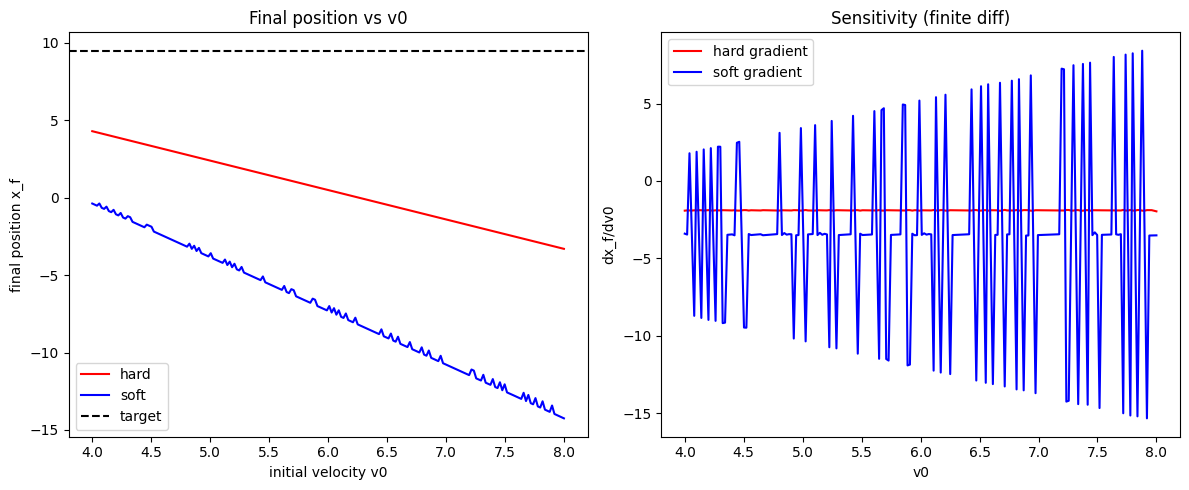


=== 优化 hard 从 v0 = 5.0 ===
iter   0: v = 4.965193, pos=2.466113 loss = 2.473778e+01, grad = 3.480660e+02
iter  20: v = 4.943915, pos=2.505915 loss = 2.445861e+01, grad = 1.060421e+01
iter  40: v = 4.922781, pos=2.546368 loss = 2.417650e+01, grad = 1.053372e+01
iter  60: v = 4.901791, pos=2.586531 loss = 2.389803e+01, grad = 1.046105e+01
iter  80: v = 4.880945, pos=2.625478 loss = 2.362953e+01, grad = 1.038895e+01

=== 优化 soft 从 v0 = 5.0 ===
iter   0: v = 23.277476, pos=-67.254648 loss = 2.945638e+03, grad = -1.827748e+05
iter  20: v = 22.743921, pos=-65.402027 loss = 2.805157e+03, grad = 2.874011e+02
iter  40: v = 22.234537, pos=-63.633434 loss = 2.674250e+03, grad = 2.811909e+02
iter  60: v = 21.748703, pos=-60.511173 loss = 2.450782e+03, grad = 2.752685e+02
iter  80: v = 21.285769, pos=-58.937161 loss = 2.341823e+03, grad = 2.696282e+02


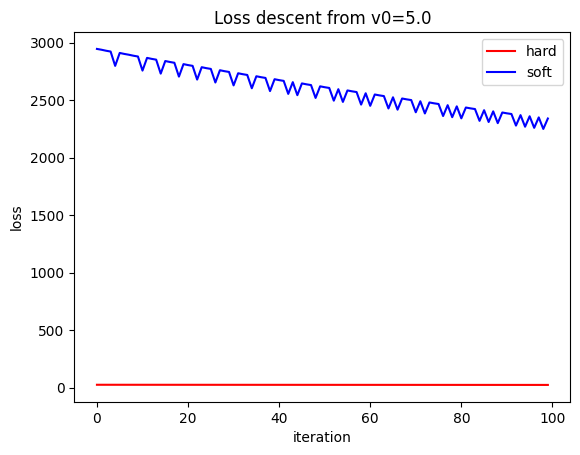


=== 优化 hard 从 v0 = 7.0 ===
iter   0: v = 6.998225, pos=-1.397868 loss = 5.938177e+01, grad = 1.775385e+01
iter  20: v = 6.962849, pos=-1.329669 loss = 5.864086e+01, grad = 1.763048e+01
iter  40: v = 6.927721, pos=-1.263296 loss = 5.792427e+01, grad = 1.750392e+01
iter  60: v = 6.892839, pos=-1.197416 loss = 5.721736e+01, grad = 1.738254e+01
iter  80: v = 6.858201, pos=-1.130722 loss = 5.650613e+01, grad = 1.726213e+01

=== 优化 soft 从 v0 = 7.0 ===
iter   0: v = 6.990828, pos=-10.749288 loss = 2.050168e+02, grad = 9.171555e+01
iter  20: v = 6.887329, pos=-9.983701 loss = 1.898073e+02, grad = 9.036928e+01
iter  40: v = 6.803049, pos=-9.696923 loss = 1.842609e+02, grad = 8.925632e+01
iter  60: v = 44.753998, pos=-141.772835 loss = 1.144174e+04, grad = 5.540637e+02
iter  80: v = 43.725696, pos=-138.195652 loss = 1.090700e+04, grad = 5.415713e+02


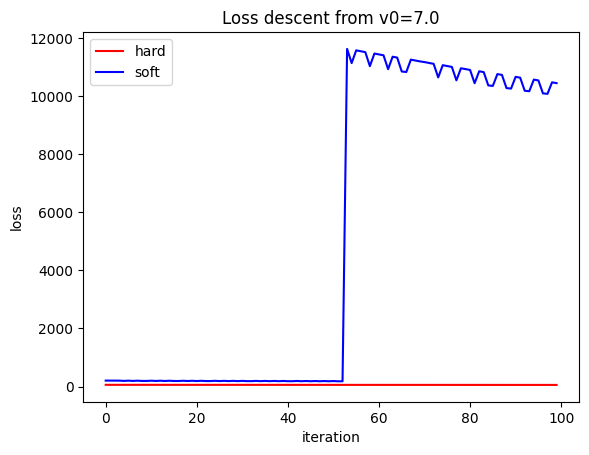

In [35]:
# ========== 扫描初速，绘制最终位置和梯度 ==========
v0_range = np.linspace(4.0, 8.0, 200)
xf_hard = [simulate_hard(v) for v in v0_range]
xf_soft = [simulate_soft(v) for v in v0_range]

# 计算数值梯度（使用中心差分）
dv = v0_range[1] - v0_range[0]
grad_hard = np.gradient(xf_hard, dv)
grad_soft = np.gradient(xf_soft, dv)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(v0_range, xf_hard, 'r-', label='hard')
plt.plot(v0_range, xf_soft, 'b-', label='soft')
plt.axhline(target, color='k', linestyle='--', label='target')
plt.xlabel('initial velocity v0')
plt.ylabel('final position x_f')
plt.legend()
plt.title('Final position vs v0')

plt.subplot(1,2,2)
plt.plot(v0_range, grad_hard, 'r-', label='hard gradient')
plt.plot(v0_range, grad_soft, 'b-', label='soft gradient')
plt.xlabel('v0')
plt.ylabel('dx_f/dv0')
plt.legend()
plt.title('Sensitivity (finite diff)')
plt.tight_layout()
plt.show()

# ========== 梯度下降优化 ==========
def finite_diff_gradient(v, contact_type, eps=1e-5):
    """计算损失对 v 的梯度（有限差分）"""
    L0 = loss(simulate_contact(v, contact_type))
    Lp = loss(simulate_contact(v + eps, contact_type))
    Lm = loss(simulate_contact(v - eps, contact_type))
    return (Lp - Lm) / (2 * eps)

def simulate_contact(v, contact_type):
    if contact_type == 'hard':
        return simulate_hard(v)
    else:
        return simulate_soft(v)

def optimize(contact_type, v_init, lr=1e-4, iters=100):
    v = v_init
    history_v = []
    history_loss = []
    print(f"\n=== 优化 {contact_type} 从 v0 = {v_init} ===")
    for i in range(iters):
        grad = finite_diff_gradient(v, contact_type)
        v -= lr * grad
        pos = simulate_contact(v, contact_type)
        L = loss(pos)
        history_v.append(v)
        history_loss.append(L)
        if i % 20 == 0:
            print(f"iter {i:3d}: v = {v:.6f}, pos={pos:.6f} loss = {L:.6e}, grad = {grad:.6e}")
    return history_v, history_loss

# 从两个不同初速开始优化
v_init_list = [5.0, 7.0]
for v_init in v_init_list:
    v_hard, L_hard = optimize('hard', v_init, lr=1e-4, iters=100)
    v_soft, L_soft = optimize('soft', v_init, lr=1e-4, iters=100)

    # 绘制损失下降曲线对比
    plt.figure()
    plt.plot(L_hard, 'r-', label='hard')
    plt.plot(L_soft, 'b-', label='soft')
    plt.xlabel('iteration')
    plt.ylabel('loss')
    plt.title(f'Loss descent from v0={v_init}')
    plt.legend()
    plt.show()

In [30]:
simulate_hard(4)
simulate_soft(4)
def finite_diff_gradient(v, contact_type, eps=1e-5):
    """计算损失对 v 的梯度（有限差分）"""
    L0 = loss(simulate_contact(v, contact_type))
    Lp = loss(simulate_contact(v + eps, contact_type))
    Lm = loss(simulate_contact(v - eps, contact_type))
    print(Lp, Lm)
    return (Lp - Lm) / (2 * eps)

def simulate_contact(v, contact_type):
    if contact_type == 'hard':
        return simulate_hard(v)
    else:
        return simulate_soft(v)
    
v = 5
print(finite_diff_gradient(v, 'hard'))
print(simulate_contact(v + 1e-5, 'hard'))
pos = simulate_contact(v, 'hard')
L = loss(pos)
print(pos, L)

25.211853399286735 25.204892080113588
348.06595865735085
2.3990347981014954
2.4000000000027533 25.204999999980448
